
# Pipeline A — Interactive Walkthrough

Runs the predictive semantic cache invalidation pipeline (`parser -> embedder ->
extractor -> predictor -> evaluator -> visualizer`) one stage at a time, timing
every stage and sub-step, and showing intermediate results as it goes.

This mirrors the orchestration in `run_experiment.py`'s `Experiment` class, but
each stage is its own cell so you can inspect, re-run, or tweak any single part
without re-running the whole pipeline. It skips `run_experiment.py`'s
per-commit-pair diagnostic JSON dumping (that's for post-hoc debugging, not
needed to see how the pipeline behaves here).

**How to use:** set the config in the next cell, then run all cells top to
bottom. The last section shows a full timing breakdown (which stage/sub-step
took the most time) and a table of every result produced along the way.


In [18]:
# =============================================================================
# SETTINGS — everything you'd normally pass as CLI flags / settings.json
# =============================================================================

CONFIG = {
    "repo_url":        "https://github.com/psf/black.git",
    "workspace_dir":   "workspace",
    "model_name":      "sentence-transformers/all-MiniLM-L6-v2",
    "device":          "cuda",  # "auto" (CUDA if available, else CPU), "cpu", "cuda", "cuda:0", ...

    "num_commits":     150,    # number of sampled commits to analyze
    "commit_stride":   15,     # step size between sampled commits
    "train_ratio":     0.7,    # fraction of commits used for training

    "threshold":       0.05,   # drift threshold for classification (ignored when threshold_mode="dynamic")
    "threshold_mode":  "dynamic",   # "fixed" or "dynamic" (85th percentile of train drift)

    "clean_mode":       False,  # strip comments/docstrings before embedding
    "context_chunking": True,   # splice dependency stubs into embedded source

    "k_values":          [5, 10],   # Recall@K values to evaluate
    "fixed_hop_values":  [1, 2],    # K values for the fixed-hop baseline
}

RANDOM_SEED = 42

## Setup — imports, timing infrastructure, and the execution plan

In [19]:
import sys, os, time, json, logging, warnings
from pathlib import Path
from contextlib import contextmanager
from typing import Dict, List, Set, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from parser.git_helper import GitHelper
from parser.tree_sitter_repo_parser import TreeSitterRepoParser, Entity
from embedder.embedding_manager import EmbeddingManager
from extractor.feature_extractor import FeatureExtractor
from extractor.gtd import GraphTransitionDescriptor
from extractor.rsd import RepositoryStateDescriptor
from predictor.predictor import DriftPredictor, train_test_split_temporal
from evaluator.evaluator import (
    Evaluator, BaselineAChangedOnly, BaselineBFullReindex, BaselineCFixedHop,
    BaselineDPageRankPropagation, PredictiveStrategy, WeightedBFSDecayStrategy,
)
from visualizer.visualize import Visualizer

logging.basicConfig(level=logging.WARNING)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

# Recall@K column names derived from CONFIG["k_values"] — never hardcode
# "recall_at_10" downstream, since k_values is meant to be changed above.
RECALL_COLS = [f"recall_at_{k}" for k in CONFIG["k_values"]]
PRIMARY_RECALL_COL = f"recall_at_{max(CONFIG['k_values'])}"


# ---- Timing infrastructure -------------------------------------------------
TIMINGS: List[dict] = []  # rows of {stage, substage, seconds}


@contextmanager
def timed(stage: str, substage: str = "_total"):
    t0 = time.perf_counter()
    try:
        yield
    finally:
        TIMINGS.append({"stage": stage, "substage": substage,
                         "seconds": time.perf_counter() - t0})


def timing_table(group_cols=("stage", "substage")) -> pd.DataFrame:
    if not TIMINGS:
        return pd.DataFrame(columns=[*group_cols, "calls", "total_seconds", "mean_seconds"])
    df = pd.DataFrame(TIMINGS)
    g = df.groupby(list(group_cols), sort=False)["seconds"].agg(["count", "sum", "mean"]).reset_index()
    g.columns = [*group_cols, "calls", "total_seconds", "mean_seconds"]
    return g.sort_values("total_seconds", ascending=False).reset_index(drop=True)


# ---- The plan ---------------------------------------------------------------
PLAN = [
    ("0. Setup",              "Clone repo, construct embedder/predictor/visualizer"),
    ("1. Harvest commits",    "Read commit history, pick sampled commits at the given stride"),
    ("2. Parse & embed",      "Per sampled commit: checkout, Tree-sitter parse, batch-embed entities"),
    ("3. Drift & features",   "Per consecutive commit pair: compute drift, GTD, modified entities, features"),
    ("4. Train predictor",    "Fit the drift classifier on training commit pairs, evaluate on held-out split"),
    ("5. Evaluate strategies","Per test commit pair: predict drift, score every cache-invalidation strategy"),
    ("6. Visualize",          "Render plots + summary report from everything collected above"),
]
print("Execution plan:")
for i, (stage, desc) in enumerate(PLAN):
    print(f"  {stage:<24s} {desc}")

Execution plan:
  0. Setup                 Clone repo, construct embedder/predictor/visualizer
  1. Harvest commits       Read commit history, pick sampled commits at the given stride
  2. Parse & embed         Per sampled commit: checkout, Tree-sitter parse, batch-embed entities
  3. Drift & features      Per consecutive commit pair: compute drift, GTD, modified entities, features
  4. Train predictor       Fit the drift classifier on training commit pairs, evaluate on held-out split
  5. Evaluate strategies   Per test commit pair: predict drift, score every cache-invalidation strategy
  6. Visualize             Render plots + summary report from everything collected above


## Stage 0 — Setup: clone repository, construct pipeline components

In [20]:
with timed("0_setup", "clone_repo"):
    repo_path = PROJECT_ROOT / CONFIG["workspace_dir"] / "black"
    git_helper = GitHelper(str(repo_path))
    ok = git_helper.clone_repo(CONFIG["repo_url"], str(repo_path))
    assert ok, "Failed to clone repository"

with timed("0_setup", "construct_components"):
    embedding_manager = EmbeddingManager(model_name=CONFIG["model_name"], clean_mode=CONFIG["clean_mode"],
                                          device=CONFIG["device"])
    predictor = DriftPredictor(model_type="random_forest", task_type="classification",
                                threshold=CONFIG["threshold"])
    rsd = RepositoryStateDescriptor()

    timestamp = time.strftime("%Y%m%d_%H%M%S")
    results_dir = PROJECT_ROOT / "results" / f"notebook_{timestamp}"
    results_dir.mkdir(parents=True, exist_ok=True)
    visualizer = Visualizer(str(results_dir))

print(f"Repo ready at: {repo_path}")
print(f"Results will be saved under: {results_dir}")
print(f"CUDA available: {torch.cuda.is_available()}"
      + (f"  ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
print(f"Embedding device resolved to: {embedding_manager.device}")

Repo ready at: c:\Users\admin\Desktop\project1\predictive-semantic-cache-invalidation\workspace\black
Results will be saved under: c:\Users\admin\Desktop\project1\predictive-semantic-cache-invalidation\results\notebook_20260904_191310
CUDA available: True  (NVIDIA GeForce RTX 3050 Laptop GPU)
Embedding device resolved to: cuda


## Stage 1 — Harvest commit history

In [21]:
with timed("1_harvest", "get_commit_history"):
    raw_commit_count = CONFIG["num_commits"] * CONFIG["commit_stride"]
    all_commits = git_helper.get_commit_history(count=raw_commit_count)

assert len(all_commits) >= CONFIG["commit_stride"] + 1, (
    f"Not enough commits ({len(all_commits)}) for stride={CONFIG['commit_stride']}"
)

sampled_commits = all_commits[::CONFIG["commit_stride"]][:CONFIG["num_commits"]]
assert len(sampled_commits) >= 2, "Need at least 2 sampled commits"

print(f"Raw commits fetched: {len(all_commits)}")
print(f"Sampled commits ({len(sampled_commits)}) at stride={CONFIG['commit_stride']}:")
for c in sampled_commits:
    print(f"  {c[:10]}")

Raw commits fetched: 2250
Sampled commits (150) at stride=15:
  497de7fa08
  5bc40707af
  584d51a042
  0095701ff9
  e5f8251704
  2ad642754b
  1d3d743dfb
  ecc294741e
  8e7848c63e
  df80103c33
  82198030ee
  6243540ae7
  987543001a
  223268aaae
  f24635635e
  642f240253
  e9a940d69e
  1b189f6cde
  75d2af2e3a
  ed50737290
  82d09eda09
  2cc42f7892
  e1ef57a29e
  9e15cacc67
  b719d85ccc
  25795c9ff5
  1610fd6bc5
  5c2dd96a69
  024c9cab55
  a00f426637
  6b381c784b
  cea13f4984
  4931ddd0b1
  188c31db7c
  5206560946
  2848e2e1d6
  673327449f
  788f87cb58
  14b28c89c2
  4b8669f502
  6bedb5c58a
  7af619b8c1
  5b6f61e765
  a33823e859
  1d3fb871be
  67726a7cf3
  24323091c8
  397b16431e
  6ebdc5a644
  f825e7ef28
  f3ab907a96
  30a332c32f
  6b935a34d0
  82c1f871d0
  8c8af4f161
  d34eb7fea3
  71117e730c
  caa3fcc2de
  beecd6fd0a
  dc8b0a4383
  d960d5d238
  65f0ea6159
  89a856d742
  07c8812937
  f1ce47bd2b
  3bba808173
  4ca4407b4a
  40fae18134
  742ddd1561
  4dd100bff2
  b97a4ac449
  8b0c7bcfda
  

## Stage 2 — Parse & embed each sampled commit

For every sampled commit: checkout, rebuild the Tree-sitter dependency graph,
and batch-generate embeddings for every entity (optionally splicing in
call-graph context per `context_chunking`).

In [22]:
def extract_signature(entity: Entity) -> str:
    # Grab just the def/class header line(s) from an entity's source.
    lines = entity.source_code.splitlines()
    def_idx = next((i for i, l in enumerate(lines)
                     if l.strip().startswith(("def ", "async def ", "class "))), -1)
    if def_idx == -1:
        return f"def {entity.entity_id.split('::')[-1]}()"
    sig_lines = []
    for i in range(def_idx, len(lines)):
        sig_lines.append(lines[i])
        if lines[i].split('#')[0].rstrip().endswith(':'):
            return "\n".join(sig_lines)
    return lines[def_idx]


def contextual_source(entity: Entity, repo_parser: TreeSitterRepoParser) -> str:
    # Entity source + one-hop dependency stubs, when context_chunking is on.
    source = entity.source_code
    if not CONFIG["context_chunking"]:
        return source

    deps = {d for d in repo_parser.get_dependencies(entity.entity_id, max_hops=1)
            if d != entity.entity_id}
    if not deps:
        return source

    stubs = []
    for dep_id in sorted(deps):
        dep = repo_parser.get_entity(dep_id)
        if not dep:
            continue
        sig = extract_signature(dep).strip()
        if not sig.endswith(':'):
            sig += ':'
        body_lines = [l.strip() for l in dep.source_code.split('\n')
                      if l.strip() and not l.strip().startswith(('def ', 'class ', '@'))]
        first_line = (body_lines[0] if body_lines else 'pass')[:120]
        stubs.append(f"{sig}\n    # Context: {first_line}\n    pass")

    return source + "\n\n# Call Graph Context\n" + "\n\n".join(stubs) if stubs else source


parsers_history: Dict[str, TreeSitterRepoParser] = {}
embeddings_history: Dict[str, Dict[str, np.ndarray]] = {}
commit_stats = []

for i, commit in enumerate(sampled_commits):
    print(f"[{i+1}/{len(sampled_commits)}] {commit[:10]}", end="  ")

    with timed("2_parse_embed", "checkout"):
        ok = git_helper.checkout_commit(commit)
    if not ok:
        print("checkout FAILED, skipping")
        continue

    with timed("2_parse_embed", "parse"):
        repo_parser = TreeSitterRepoParser(str(repo_path))
        repo_parser.parse_directory(str(repo_path))
        parsers_history[commit] = repo_parser

    entities = repo_parser.get_all_entities()
    entity_sources = {e.entity_id: contextual_source(e, repo_parser) for e in entities}

    with timed("2_parse_embed", "embed"):
        embeddings = embedding_manager.generate_embeddings_batch(entity_sources) if entity_sources else {}
    embeddings_history[commit] = embeddings

    with timed("2_parse_embed", "rsd_add_commit"):
        rsd.add_commit(commit_hash=commit, repo_parser=repo_parser, embeddings=embeddings,
                        modification_history={}, previous_drifts={},
                        commit_index=i, total_commits=len(sampled_commits))

    print(f"entities={len(entities)}  embeddings={len(embeddings)}")
    commit_stats.append({"commit": commit[:10], "n_entities": len(entities), "n_embeddings": len(embeddings)})

pd.DataFrame(commit_stats)

[1/150] 497de7fa08  

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

entities=232  embeddings=232
[2/150] 5bc40707af  

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

entities=690  embeddings=690
[150/150] 42bc212d77  

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

entities=698  embeddings=698


,commit,n_entities,n_embeddings
0,497de7fa08,232,232
1,5bc40707af,233,233
2,584d51a042,235,235
3,0095701ff9,252,252
4,e5f8251704,255,255
...,...,...,...
145,9e8749525b,675,675
146,d2f014ca5d,680,680
147,beb438cd63,685,685
148,a51a0be79c,690,690


## Stage 3 — Compute drift & extract features for each consecutive commit pair

For each `(commit_a, commit_b)` pair: cosine drift between embeddings, the
Graph Transition Descriptor, which entities were *semantically* modified (an
AST-normalization filter drops purely cosmetic diffs), and the full feature
matrix fed to the predictor.

In [23]:
import ast, re as _re


def normalize_source(code_str: str) -> str:
    # AST-normalize source so cosmetic-only diffs (whitespace/comments) don't count as changes.
    try:
        return ast.dump(ast.parse(code_str), annotate_fields=False)
    except Exception:
        cleaned = _re.sub(r'#.*', '', code_str)
        return " ".join(cleaned.split())


modification_history: Dict[str, List[str]] = {}
previous_drifts: Dict[str, float] = {}
gtd_history: Dict[Tuple[str, str], GraphTransitionDescriptor] = {}
drifts_history: Dict[Tuple[str, str], Dict[str, float]] = {}
features_history: Dict[Tuple[str, str], pd.DataFrame] = {}
pair_stats = []

for i in range(1, len(sampled_commits)):
    commit_a, commit_b = sampled_commits[i - 1], sampled_commits[i]
    if commit_a not in embeddings_history or commit_b not in embeddings_history:
        continue
    emb_a, emb_b = embeddings_history[commit_a], embeddings_history[commit_b]
    if not emb_a or not emb_b:
        continue

    repo_parser_b = parsers_history[commit_b]

    with timed("3_drift_features", "compute_drift"):
        drifts = embedding_manager.compute_all_drifts(emb_a, emb_b)

    with timed("3_drift_features", "gtd"):
        gtd = GraphTransitionDescriptor()
        gtd.compute(parser_a=parsers_history.get(commit_a), parser_b=repo_parser_b, drifts=drifts)
        gtd_history[(commit_a, commit_b)] = gtd

    with timed("3_drift_features", "modified_entities"):
        modified_files = git_helper.get_modified_files(commit_a, commit_b)
        candidate_modified = {
            eid for eid in drifts
            if (e := repo_parser_b.get_entity(eid)) and e.file_path in modified_files
        }
        for e in repo_parser_b.get_all_entities():
            if e.file_path in modified_files:
                candidate_modified.add(e.entity_id)

        parser_prev = parsers_history.get(commit_a)
        modified_entities = set()
        for eid in candidate_modified:
            prev_e = parser_prev.entities.get(eid) if parser_prev else None
            curr_e = repo_parser_b.entities.get(eid)
            if not prev_e or not curr_e:
                modified_entities.add(eid)
            elif normalize_source(prev_e.source_code) != normalize_source(curr_e.source_code):
                modified_entities.add(eid)

    entity_ids = [eid for eid in drifts if eid in repo_parser_b.get_graph()]
    if not entity_ids:
        continue

    with timed("3_drift_features", "extract_features"):
        feature_extractor = FeatureExtractor(repo_parser_b)
        features_df = feature_extractor.extract_features_batch(
            entity_ids, commit_a, commit_b, modified_entities,
            modification_history, previous_drifts, git_helper, gtd=gtd,
        )

    for eid in modified_entities:
        feature_extractor.update_modification_history(eid, commit_b, modification_history)
    previous_drifts.update(drifts)

    drifts_history[(commit_a, commit_b)] = drifts
    features_history[(commit_a, commit_b)] = features_df

    pair_stats.append({
        "pair": f"{commit_a[:8]}->{commit_b[:8]}",
        "n_entities": len(drifts),
        "n_modified": len(modified_entities),
        "mean_drift": float(np.mean(list(drifts.values()))) if drifts else 0.0,
    })
    print(f"{commit_a[:8]}->{commit_b[:8]}  entities={len(drifts)}  modified={len(modified_entities)}")

pd.DataFrame(pair_stats)

497de7fa->5bc40707  entities=231  modified=25
5bc40707->584d51a0  entities=232  modified=16
584d51a0->0095701f  entities=235  modified=38
0095701f->e5f82517  entities=252  modified=6
e5f82517->2ad64275  entities=250  modified=79
2ad64275->1d3d743d  entities=257  modified=23
1d3d743d->ecc29474  entities=263  modified=6
ecc29474->8e7848c6  entities=263  modified=25
8e7848c6->df80103c  entities=270  modified=18
df80103c->82198030  entities=275  modified=14
82198030->6243540a  entities=279  modified=16
6243540a->98754300  entities=282  modified=16
98754300->223268aa  entities=287  modified=18
223268aa->f2463563  entities=290  modified=26
f2463563->642f2402  entities=297  modified=13
642f2402->e9a940d6  entities=298  modified=23
e9a940d6->1b189f6c  entities=299  modified=18
1b189f6c->75d2af2e  entities=301  modified=11
75d2af2e->ed507372  entities=305  modified=12
ed507372->82d09eda  entities=308  modified=9
82d09eda->2cc42f78  entities=310  modified=17
2cc42f78->e1ef57a2  entities=298  mod

,pair,n_entities,n_modified,mean_drift
0,497de7fa->5bc40707,231,25,0.003485
1,5bc40707->584d51a0,232,16,0.001398
2,584d51a0->0095701f,235,38,0.008020
3,0095701f->e5f82517,252,6,0.000067
4,e5f82517->2ad64275,250,79,0.011839
...,...,...,...,...
144,bf446601->9e874952,673,9,0.000148
145,9e874952->d2f014ca,675,19,0.000988
146,d2f014ca->beb438cd,680,22,0.001285
147,beb438cd->a51a0be7,685,32,0.001060


## Finalize RSD & chronological train/test split

In [24]:
with timed("3_drift_features", "finalize_rsd_split"):
    rsd.build_all_rsds()
    split_idx = max(1, int(len(sampled_commits) * CONFIG["train_ratio"]))
    train_commits = sampled_commits[:split_idx]
    test_commits = sampled_commits[split_idx:]

print(f"Train commits: {len(train_commits)}   Test commits: {len(test_commits)}")
print()
print(rsd.summary_table())

Train commits: 105   Test commits: 45

Commit      S       T       M       C       E     
--------------------------------------------------
497de7fa    0.3159  0.4309  0.0021  0.2790  0.0004
5bc40707    0.3202  0.4295  0.0022  0.2775  0.0004
584d51a0    0.3185  0.4218  0.0020  0.2744  0.0004
0095701f    0.3237  0.3492  0.0016  0.2339  0.0004
e5f82517    0.3235  0.3460  0.0017  0.2313  0.0004
2ad64275    0.3326  0.3397  0.0016  0.2443  0.0004
1d3d743d    0.3357  0.3378  0.0018  0.2527  0.0004
ecc29474    0.3363  0.3378  0.0018  0.2520  0.0004
8e7848c6    0.3394  0.3442  0.0017  0.2695  0.0004
df80103c    0.3405  0.3165  0.0013  0.2759  0.0004
82198030    0.3403  0.3142  0.0014  0.2733  0.0004
6243540a    0.3422  0.3155  0.0015  0.2790  0.0005
98754300    0.3438  0.3232  0.0015  0.2807  0.0005
223268aa    0.3451  0.3214  0.0017  0.2835  0.0005
f2463563    0.3475  0.3280  0.0013  0.2915  0.0005
642f2402    0.3504  0.3364  0.0014  0.2965  0.0005
e9a940d6    0.3530  0.3361  0.0016  0.3024 

## Stage 4 — Train the drift predictor

In [25]:
with timed("4_train", "combine_training_data"):
    all_features, all_drifts = [], {}
    for i in range(1, len(train_commits)):
        key = (train_commits[i - 1], train_commits[i])
        if key not in features_history or key not in drifts_history:
            continue
        prefix = f"{key[0][:8]}_{key[1][:8]}"
        fdf = features_history[key].copy()
        fdf.index = [f"{prefix}::{eid}" for eid in fdf.index]
        all_features.append(fdf)
        all_drifts.update({f"{prefix}::{eid}": d for eid, d in drifts_history[key].items()})

    assert all_features, "No training data — widen num_commits/commit_stride"
    combined_features = pd.concat(all_features, ignore_index=False)
    combined_features = combined_features[~combined_features.index.duplicated(keep="first")]

threshold = CONFIG["threshold"]
if CONFIG["threshold_mode"] == "dynamic":
    # Most entities in any given commit pair are untouched (directly or via
    # context) and have exactly-zero drift; including them in the percentile
    # collapses the threshold to ~0 regardless of the percentile chosen. Take
    # the percentile over entities that actually drifted at all instead.
    vals = [v for v in all_drifts.values() if not np.isnan(v)]
    nonzero_vals = [v for v in vals if v > 1e-9]
    if nonzero_vals:
        threshold = float(np.percentile(nonzero_vals, 85))
        predictor.threshold = threshold
        print(f"Dynamic threshold -> {threshold:.4f} (85th percentile of nonzero training drift, "
              f"{len(nonzero_vals)}/{len(vals)} rows had any drift)")
    elif vals:
        print(f"All {len(vals)} training drift values are ~zero; "
              f"keeping configured threshold {threshold:.4f} instead of a degenerate dynamic one")

with timed("4_train", "prepare_and_split"):
    predictor.prepare_data(combined_features, all_drifts)
    X_train, X_test, y_train, y_test = train_test_split_temporal(
        combined_features, all_drifts, train_ratio=CONFIG["train_ratio"]
    )

with timed("4_train", "fit"):
    train_metrics = predictor.train(X_train, y_train)

with timed("4_train", "evaluate_holdout"):
    test_metrics = predictor.evaluate(X_test, y_test)

with timed("4_train", "save_model"):
    model_path = results_dir / "drift_predictor.pkl"
    predictor.save(str(model_path))

print(f"Trained on {len(combined_features)} entities ({len(X_train)} train / {len(X_test)} test rows)")
pd.DataFrame([{"split": "train", **train_metrics}, {"split": "test", **test_metrics}])

Dynamic threshold -> 0.0201 (85th percentile of nonzero training drift, 4844/43157 rows had any drift)
Trained on 43157 entities (25634 train / 17523 test rows)


,split,train_accuracy,train_f1,train_precision,train_recall,test_accuracy,test_f1,test_precision,test_recall,test_pr_auc
0,train,0.982289,0.692412,0.529534,1.0,NaN,NaN,NaN,NaN,NaN
1,test,NaN,NaN,NaN,NaN,0.982138,0.523592,0.390023,0.796296,0.439396


## Stage 5 — Evaluate cache-invalidation strategies

For each test commit pair: predict drift with the trained model, generate a
handful of synthetic retrieval queries, then score every invalidation
strategy (baselines + the predictive one) individually so their timings show
up separately in the final summary.

In [26]:
STRATEGIES = {
    "baseline_a_changed_only":      lambda: BaselineAChangedOnly(),
    "baseline_b_full_reindex":      lambda: BaselineBFullReindex(),
    "baseline_c_fixed_hop_k1":      lambda: BaselineCFixedHop(k=1),
    "baseline_c_fixed_hop_k2":      lambda: BaselineCFixedHop(k=2),
    "proposed_predictive":          lambda: PredictiveStrategy(),
    "baseline_d_pagerank_propagation": lambda: BaselineDPageRankPropagation(top_fraction=0.3),
    "weighted_bfs_decay":           lambda: WeightedBFSDecayStrategy(threshold=0.05),
}


def extract_docstring_summary(source: str) -> Optional[str]:
    m = _re.search(r'"{3}(.*?)"{3}', source, _re.DOTALL) or _re.search(r"'{3}(.*?)'{3}", source, _re.DOTALL)
    if m:
        first_line = m.group(1).strip().split('\n')[0].strip()
        if len(first_line) > 5:
            return first_line
    return None


def generate_queries(repo_parser, drifts, num_queries=20) -> Dict[str, np.ndarray]:
    entities = repo_parser.get_all_entities()
    if drifts and len(drifts) >= num_queries:
        ranked = sorted(drifts.items(), key=lambda x: x[1], reverse=True)
        n_drifted = int(num_queries * 0.75)
        selected_ids = [e for e, _ in ranked[:n_drifted]] + [e for e, _ in ranked[-(num_queries - n_drifted):]]
        selected = [e for e in (repo_parser.get_entity(i) for i in selected_ids) if e]
    else:
        selected = entities[:num_queries]

    queries = {}
    for i, entity in enumerate(selected):
        doc = extract_docstring_summary(entity.source_code)
        func_name = entity.entity_id.split('::')[-1]
        file_name = entity.file_path.split('/')[-1]
        text = (f"Which function implements the following functionality: {doc}?" if doc
                else f"How is the function {func_name} in {file_name} implemented and what is its purpose?")
        queries[f"query_{i}"] = embedding_manager.generate_embedding(f"query_{i}", text)
    return queries


evaluator = Evaluator(embedding_manager, parsers_history.get(sampled_commits[0]))
strategy_rows = []
all_predictions, all_labels = [], []
drift_by_distance: Dict[int, List[float]] = {}

for i in range(1, len(test_commits)):
    commit_a, commit_b = test_commits[i - 1], test_commits[i]
    key = (commit_a, commit_b)
    if key not in drifts_history or key not in features_history:
        continue

    drifts, features_df = drifts_history[key], features_history[key]
    repo_parser_b = parsers_history[commit_b]

    with timed("5_evaluate", "predict"):
        X, y_true = predictor.prepare_data(features_df, drifts)
        aligned_ids = predictor.last_common_ids
        y_prob = predictor.predict_proba(X)
        y_pred = y_prob[:, 1] if y_prob is not None else predictor.predict(X)
        y_pred_class = predictor.predict(X)

    y_true_class = (y_true >= threshold).astype(int)
    all_predictions.extend(y_pred_class)
    all_labels.extend(y_true_class)
    predicted_drifts = {eid: d for eid, d in zip(aligned_ids, y_pred)}

    ground_truth_embeddings = embeddings_history.get(commit_b, {})
    modified_files = git_helper.get_modified_files(commit_a, commit_b)
    modified_entities = {
        eid for eid in drifts
        if (e := repo_parser_b.get_entity(eid)) and e.file_path in modified_files
    }

    with timed("5_evaluate", "generate_queries"):
        queries = generate_queries(repo_parser_b, drifts)

    embedding_manager.embeddings = embeddings_history[commit_a].copy()
    evaluator.repo_parser = repo_parser_b

    for name, make_strategy in STRATEGIES.items():
        with timed("5_evaluate", f"strategy::{name}"):
            metrics = evaluator.evaluate_strategy(
                make_strategy(), ground_truth_embeddings, predicted_drifts,
                modified_entities, queries, threshold=threshold, k_values=CONFIG["k_values"],
            )
        strategy_rows.append({"pair": f"{commit_a[:8]}->{commit_b[:8]}", "strategy": name, **metrics})

    for eid, drift in drifts.items():
        dist = 0 if eid in modified_entities else repo_parser_b.get_nearest_modified_distance(eid, modified_entities)
        if dist is not None:
            drift_by_distance.setdefault(dist, []).append(drift)

    print(f"{commit_a[:8]}->{commit_b[:8]} evaluated across {len(STRATEGIES)} strategies")

strategy_df = pd.DataFrame(strategy_rows)
strategy_df.shape

2f68ac85->7c4fe83b evaluated across 7 strategies
7c4fe83b->716fa080 evaluated across 7 strategies
716fa080->e9356c1f evaluated across 7 strategies
e9356c1f->1b08cbc6 evaluated across 7 strategies
1b08cbc6->935f303a evaluated across 7 strategies
935f303a->8de4be51 evaluated across 7 strategies
8de4be51->5515a5ac evaluated across 7 strategies
5515a5ac->f4c7be54 evaluated across 7 strategies
f4c7be54->ec4a1525 evaluated across 7 strategies
ec4a1525->ce28be27 evaluated across 7 strategies
ce28be27->c3592466 evaluated across 7 strategies
c3592466->a5196e6f evaluated across 7 strategies
a5196e6f->177e3063 evaluated across 7 strategies
177e3063->23dfc5b2 evaluated across 7 strategies
23dfc5b2->7b5a6572 evaluated across 7 strategies
7b5a6572->66e2b115 evaluated across 7 strategies
66e2b115->e4aaa8a9 evaluated across 7 strategies
e4aaa8a9->b9c63230 evaluated across 7 strategies
b9c63230->b1c4dd96 evaluated across 7 strategies
b1c4dd96->058da5f8 evaluated across 7 strategies
058da5f8->484a6696 e

(308, 11)

In [27]:
metric_cols = [*RECALL_COLS, "mrr", "ndcg_at_10", "rank_correlation",
               "update_percentage", "entities_updated", "total_entities"]
averaged_results = (
    strategy_df.groupby("strategy")[metric_cols].mean()
    .sort_values(PRIMARY_RECALL_COL, ascending=False)
)
averaged_results

,recall_at_5,recall_at_10,mrr,ndcg_at_10,rank_correlation,update_percentage,entities_updated,total_entities
strategy,,,,,,,,
baseline_a_changed_only,0.999091,1.000000,1.0,1.000000,0.999962,35.071452,231.750000,655.795455
baseline_b_full_reindex,1.000000,1.000000,1.0,1.000000,1.000000,99.330248,651.409091,655.795455
baseline_c_fixed_hop_k1,0.999318,1.000000,1.0,1.000000,0.999964,42.851276,282.818182,655.795455
baseline_c_fixed_hop_k2,0.999318,1.000000,1.0,1.000000,0.999964,47.683195,314.500000,655.795455
baseline_d_pagerank_propagation,0.999091,1.000000,1.0,1.000000,0.999962,39.525652,260.613636,655.795455
weighted_bfs_decay,0.999318,1.000000,1.0,1.000000,0.999966,49.036770,323.386364,655.795455
proposed_predictive,0.999773,0.999659,1.0,0.999783,0.999992,5.591196,37.090909,655.795455


## Stage 6 — Visualizations & summary report

`Visualizer` forces matplotlib's non-interactive `Agg` backend and closes each
figure right after saving it to PNG (so it works headlessly from
`run_experiment.py`). That means a plain `plt.show()` right after would render
nothing here — instead we display the saved PNG files directly.

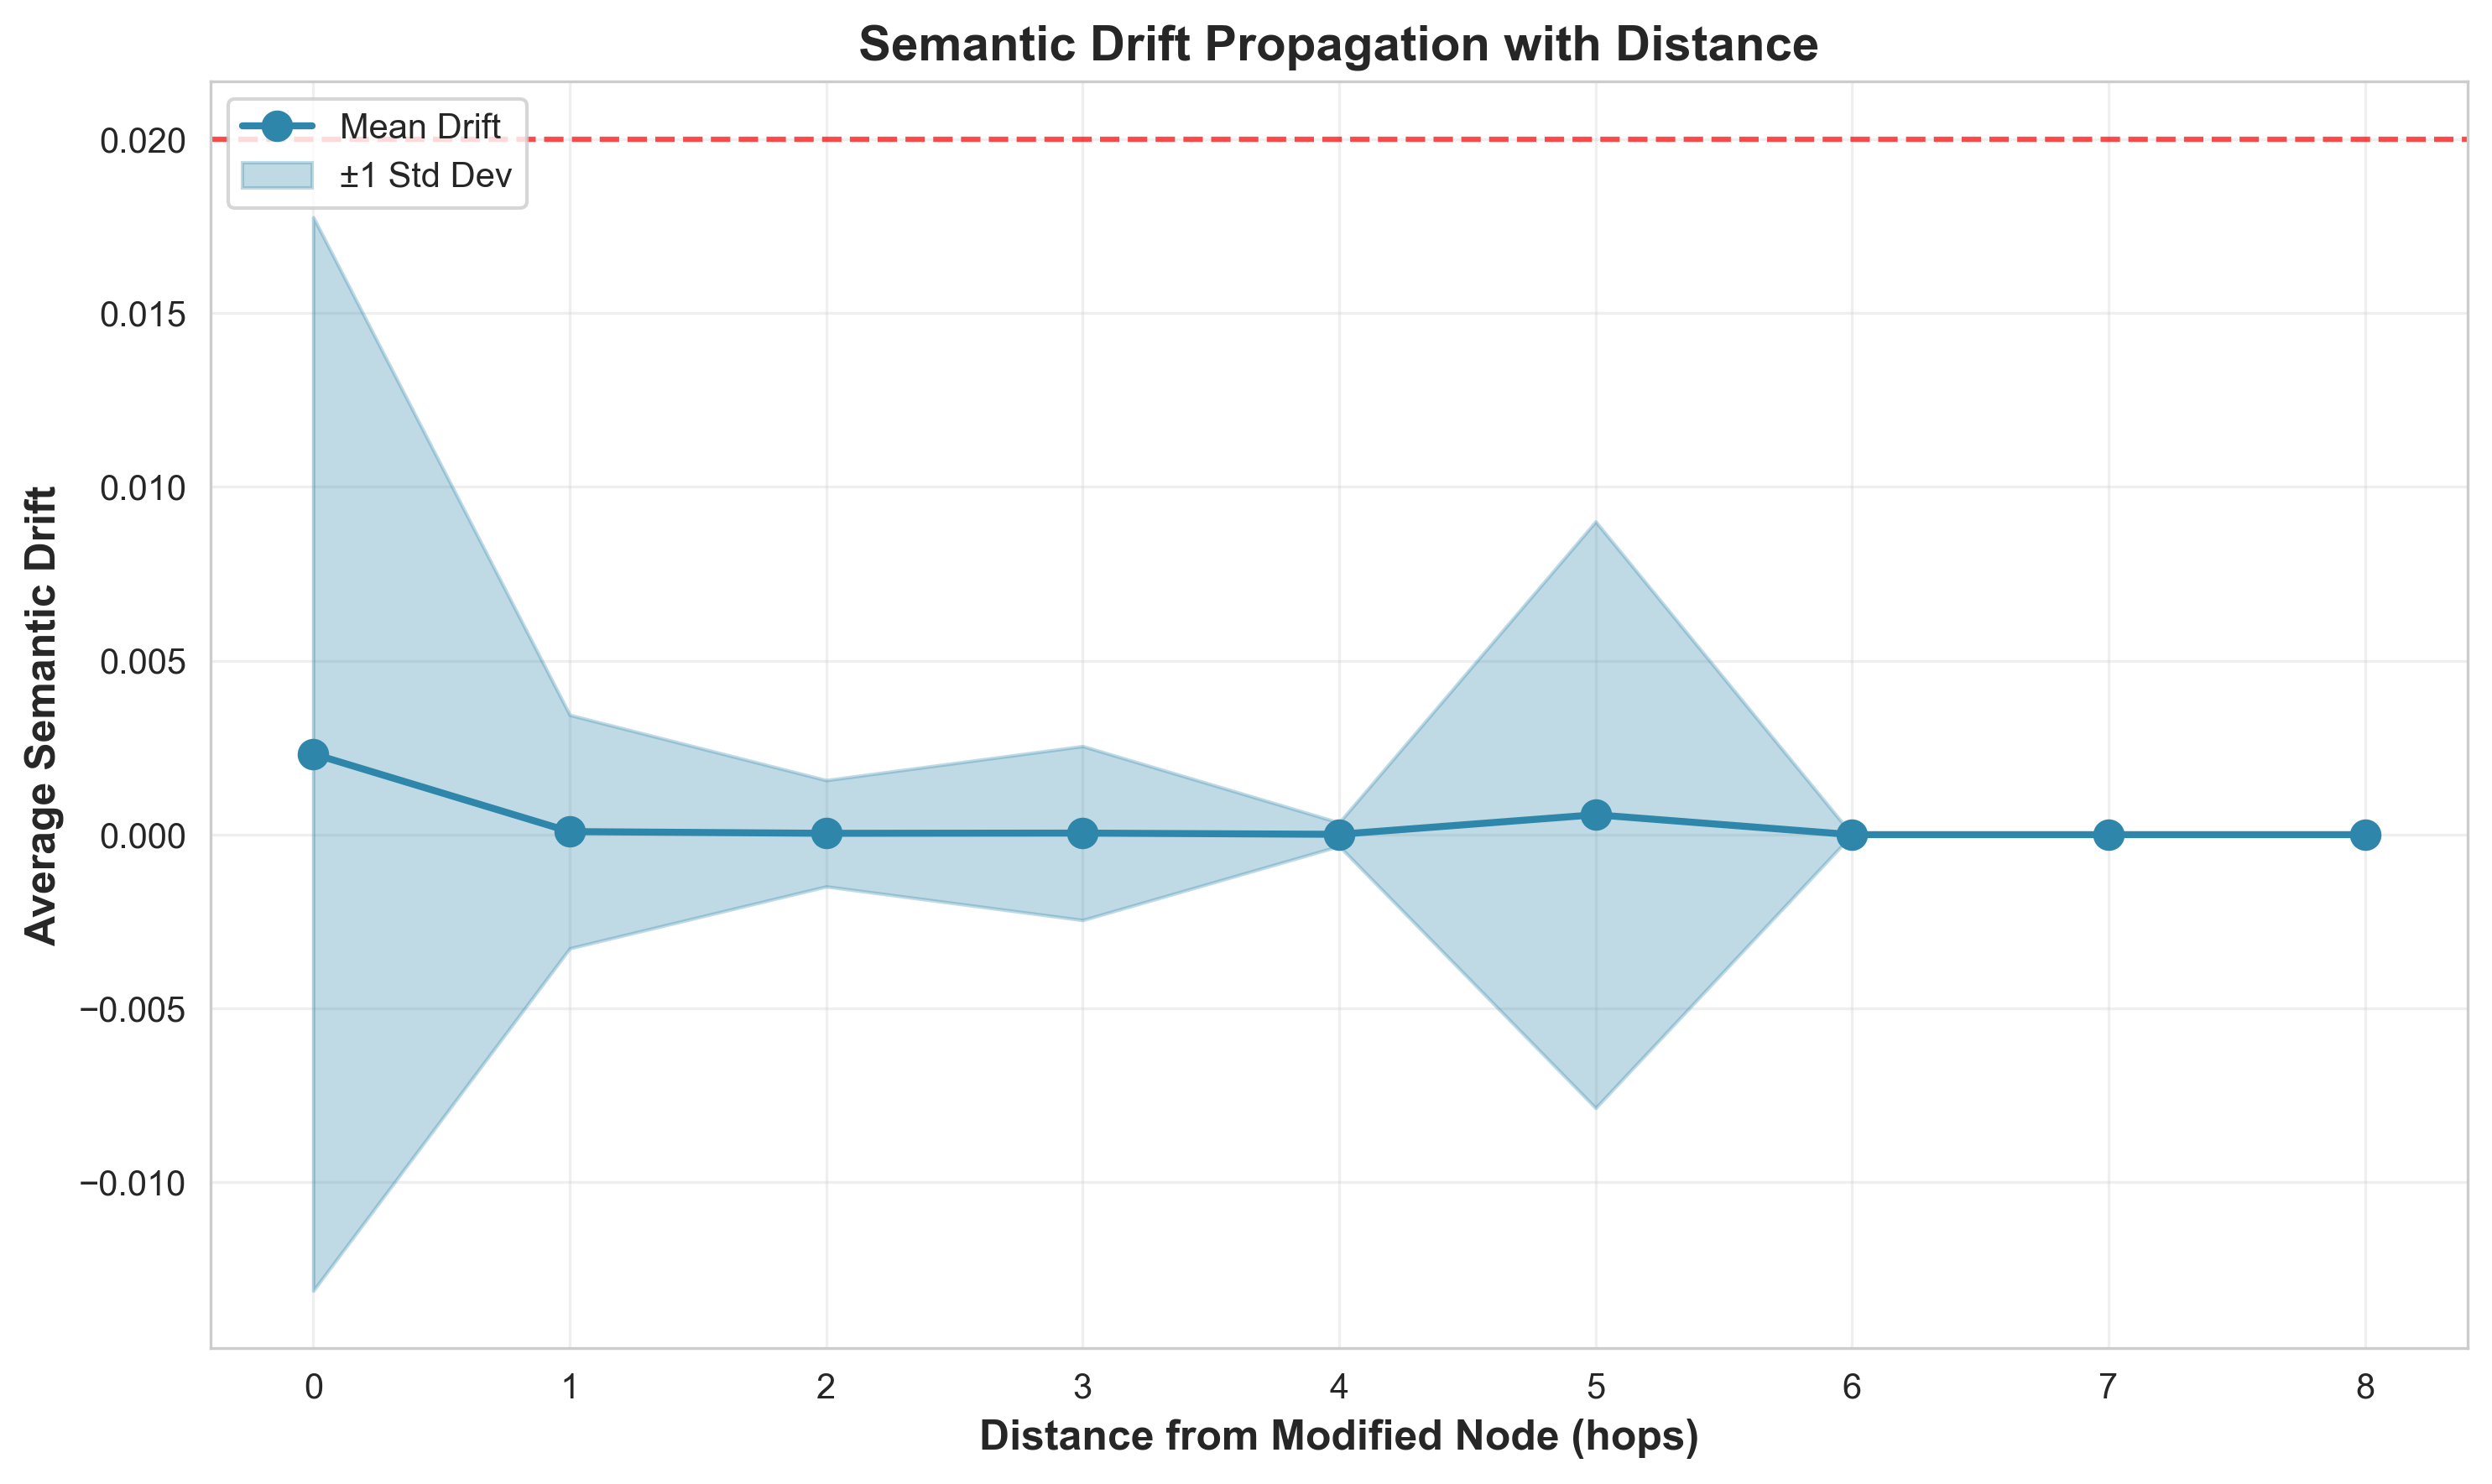

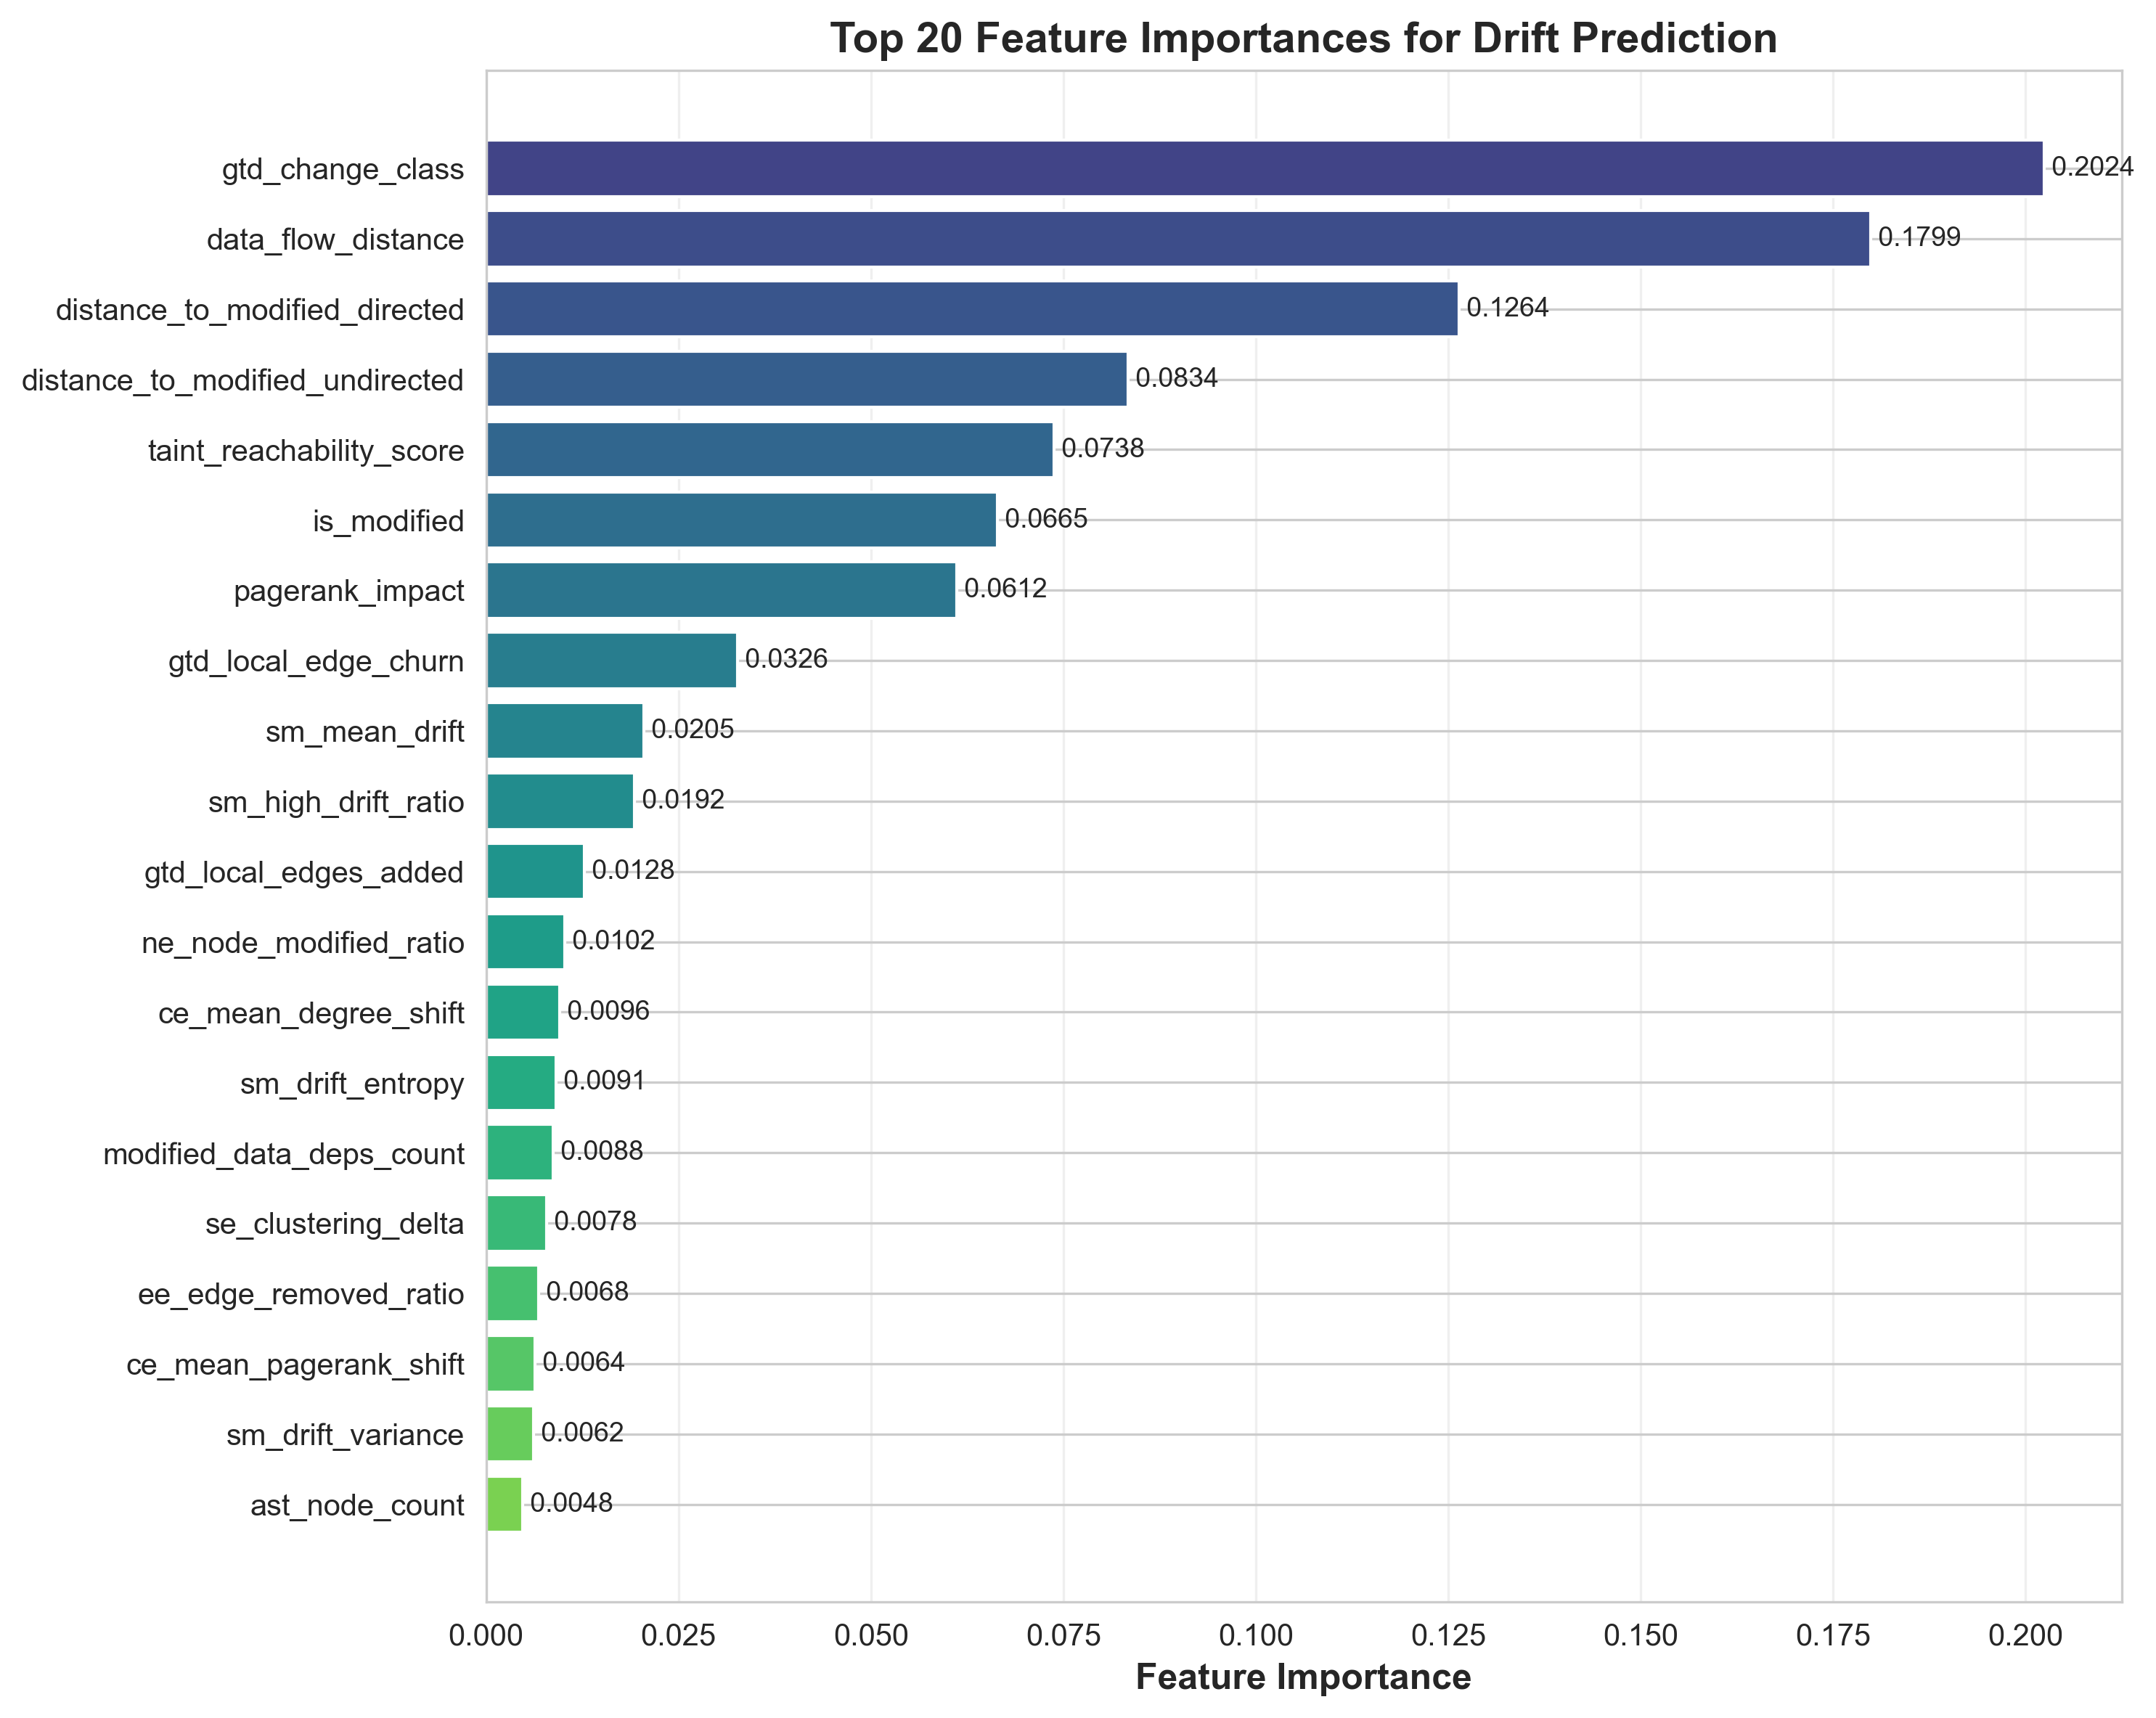

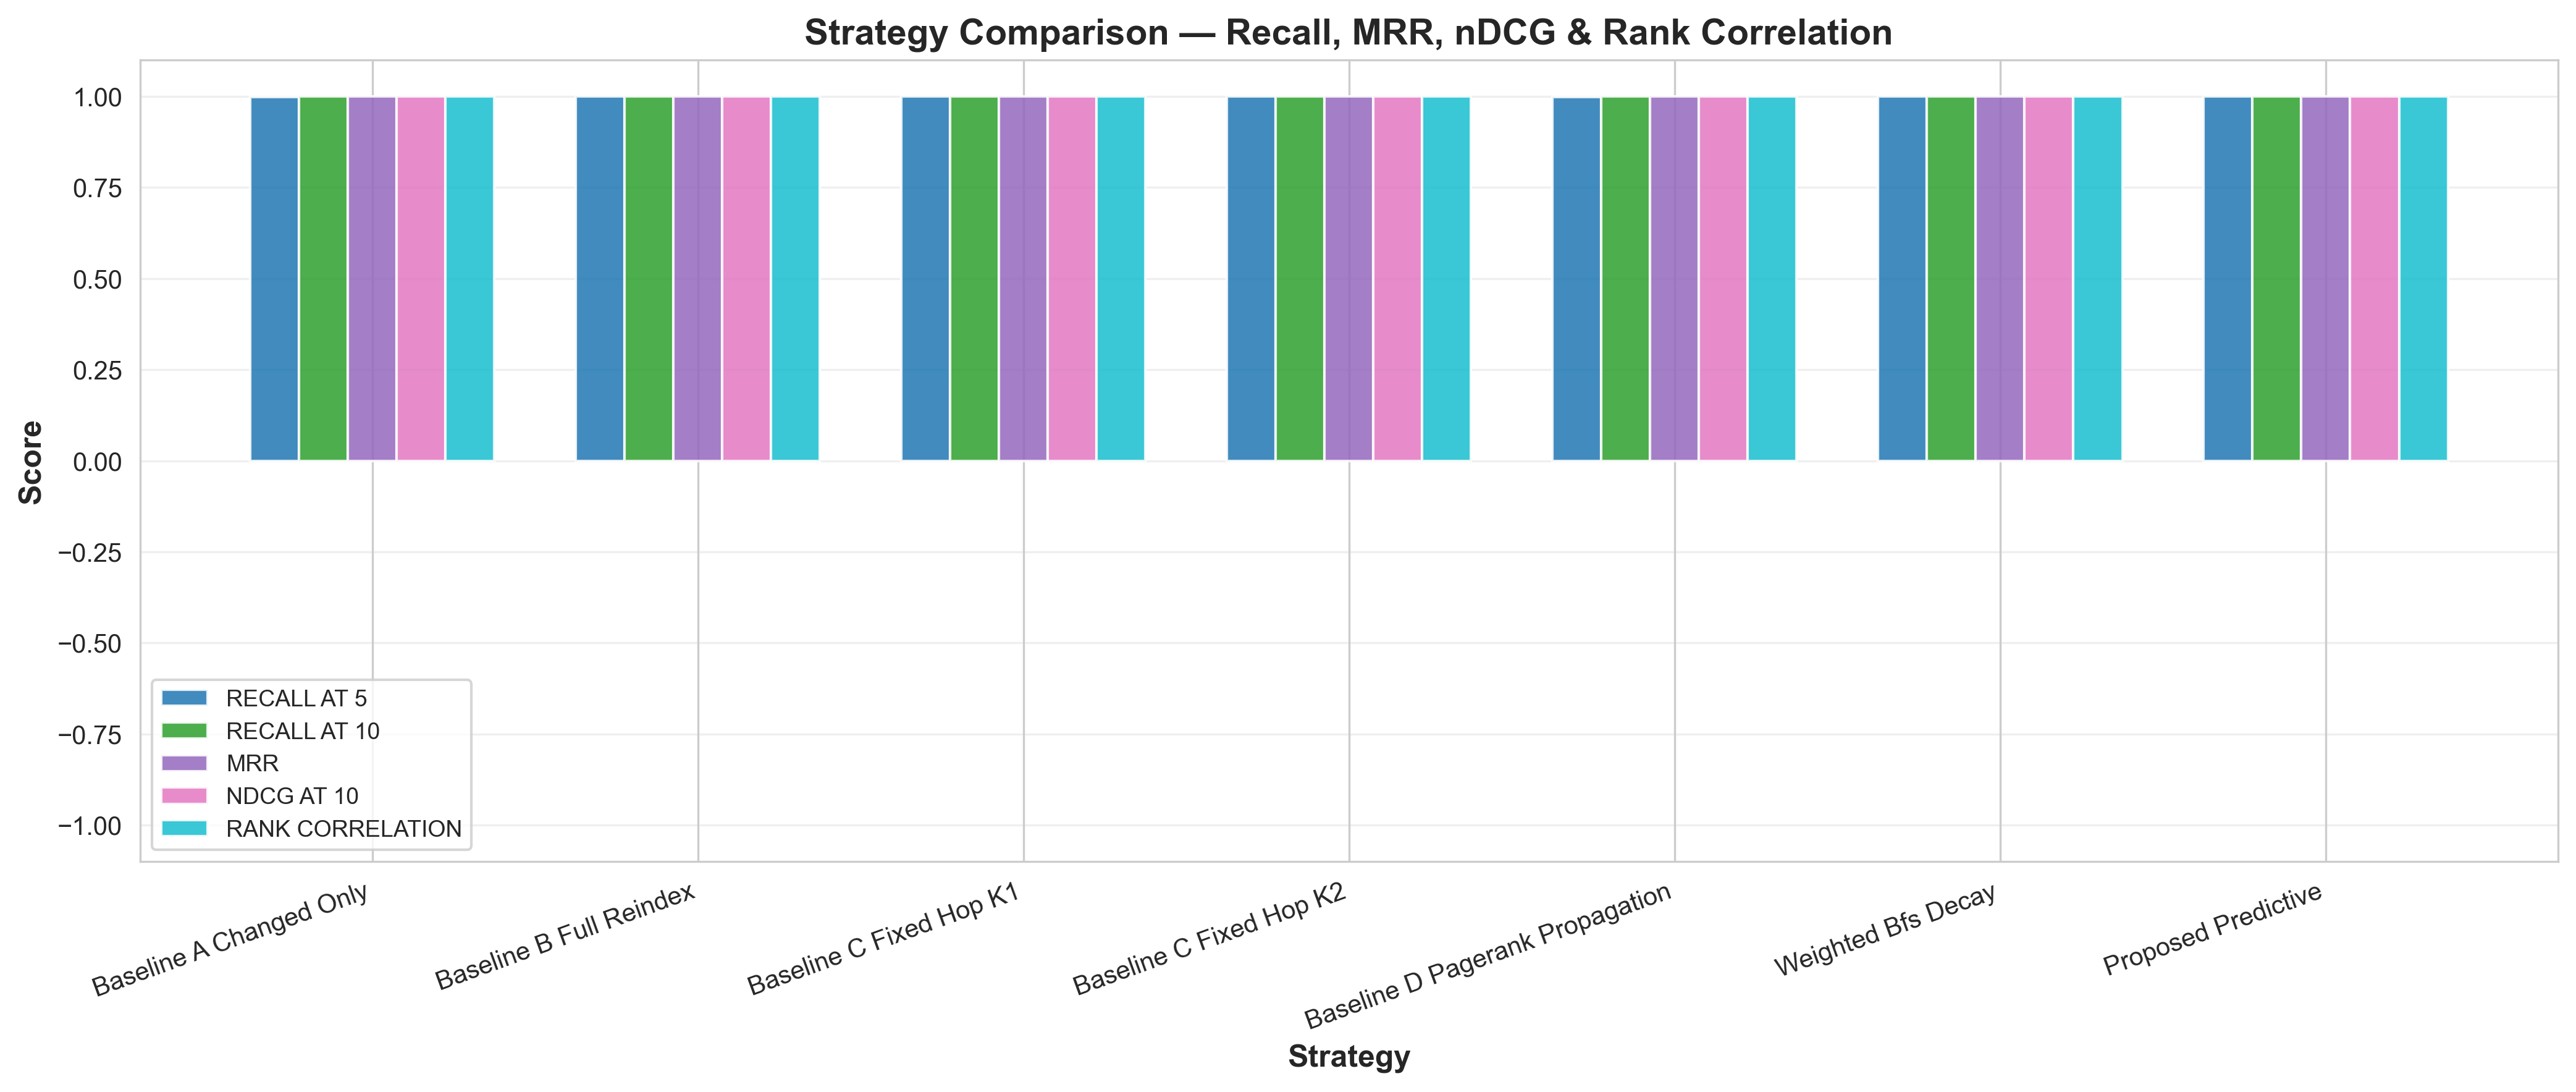

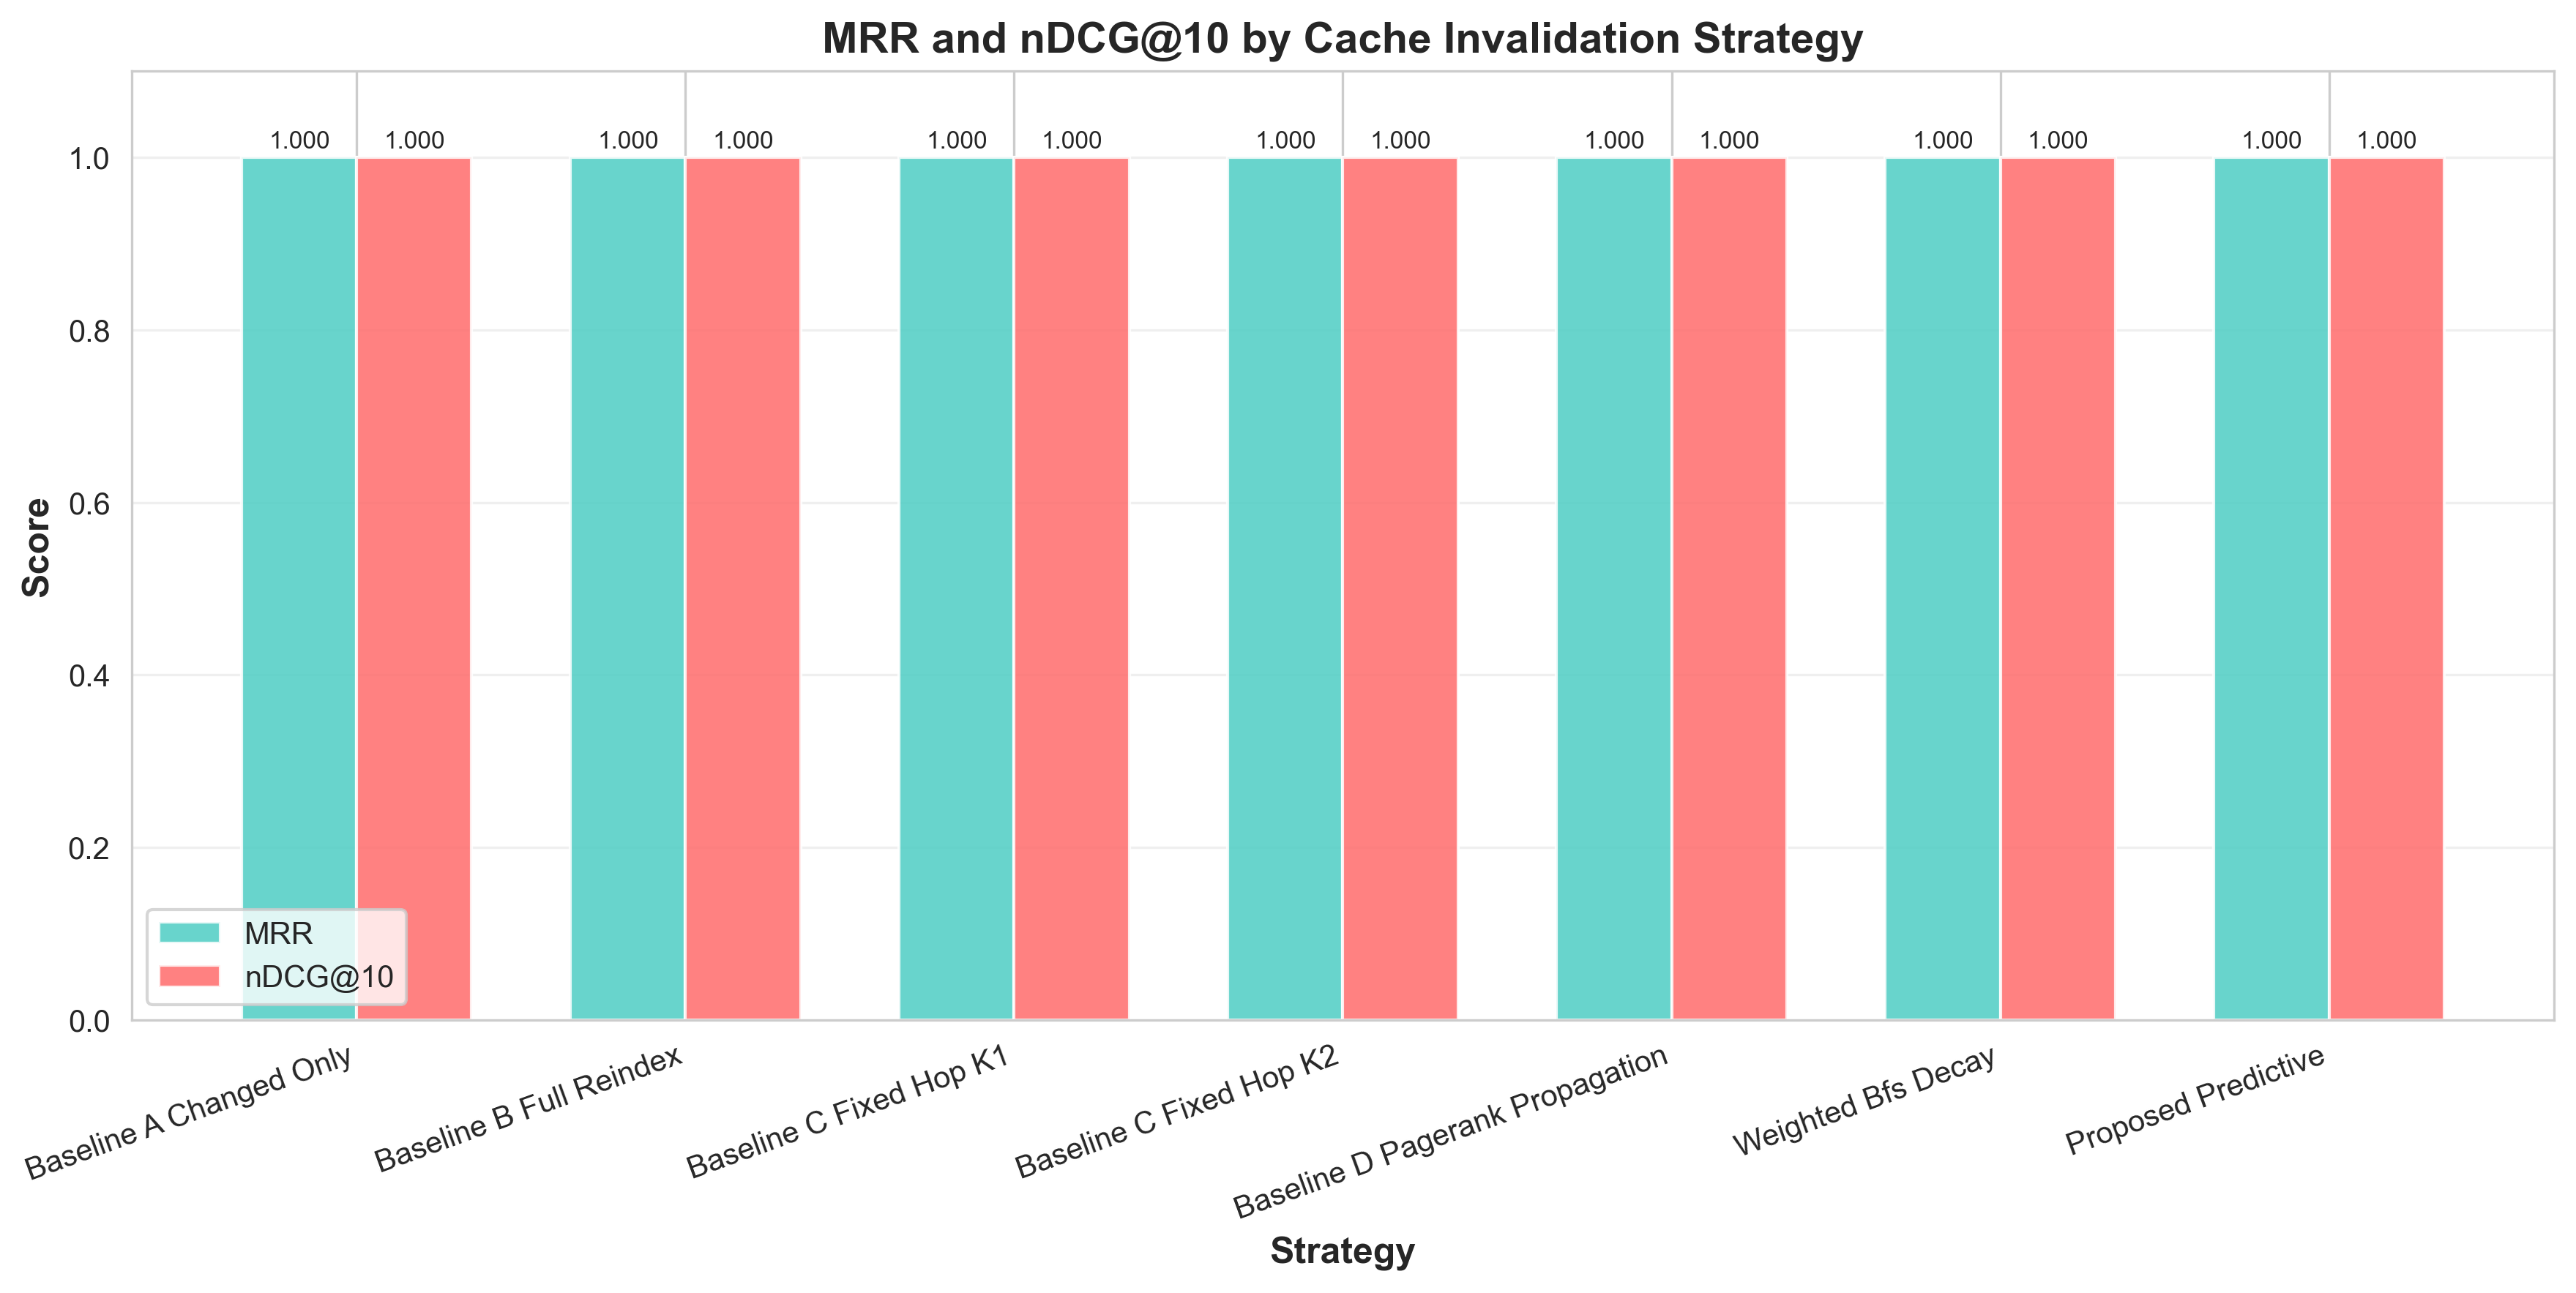

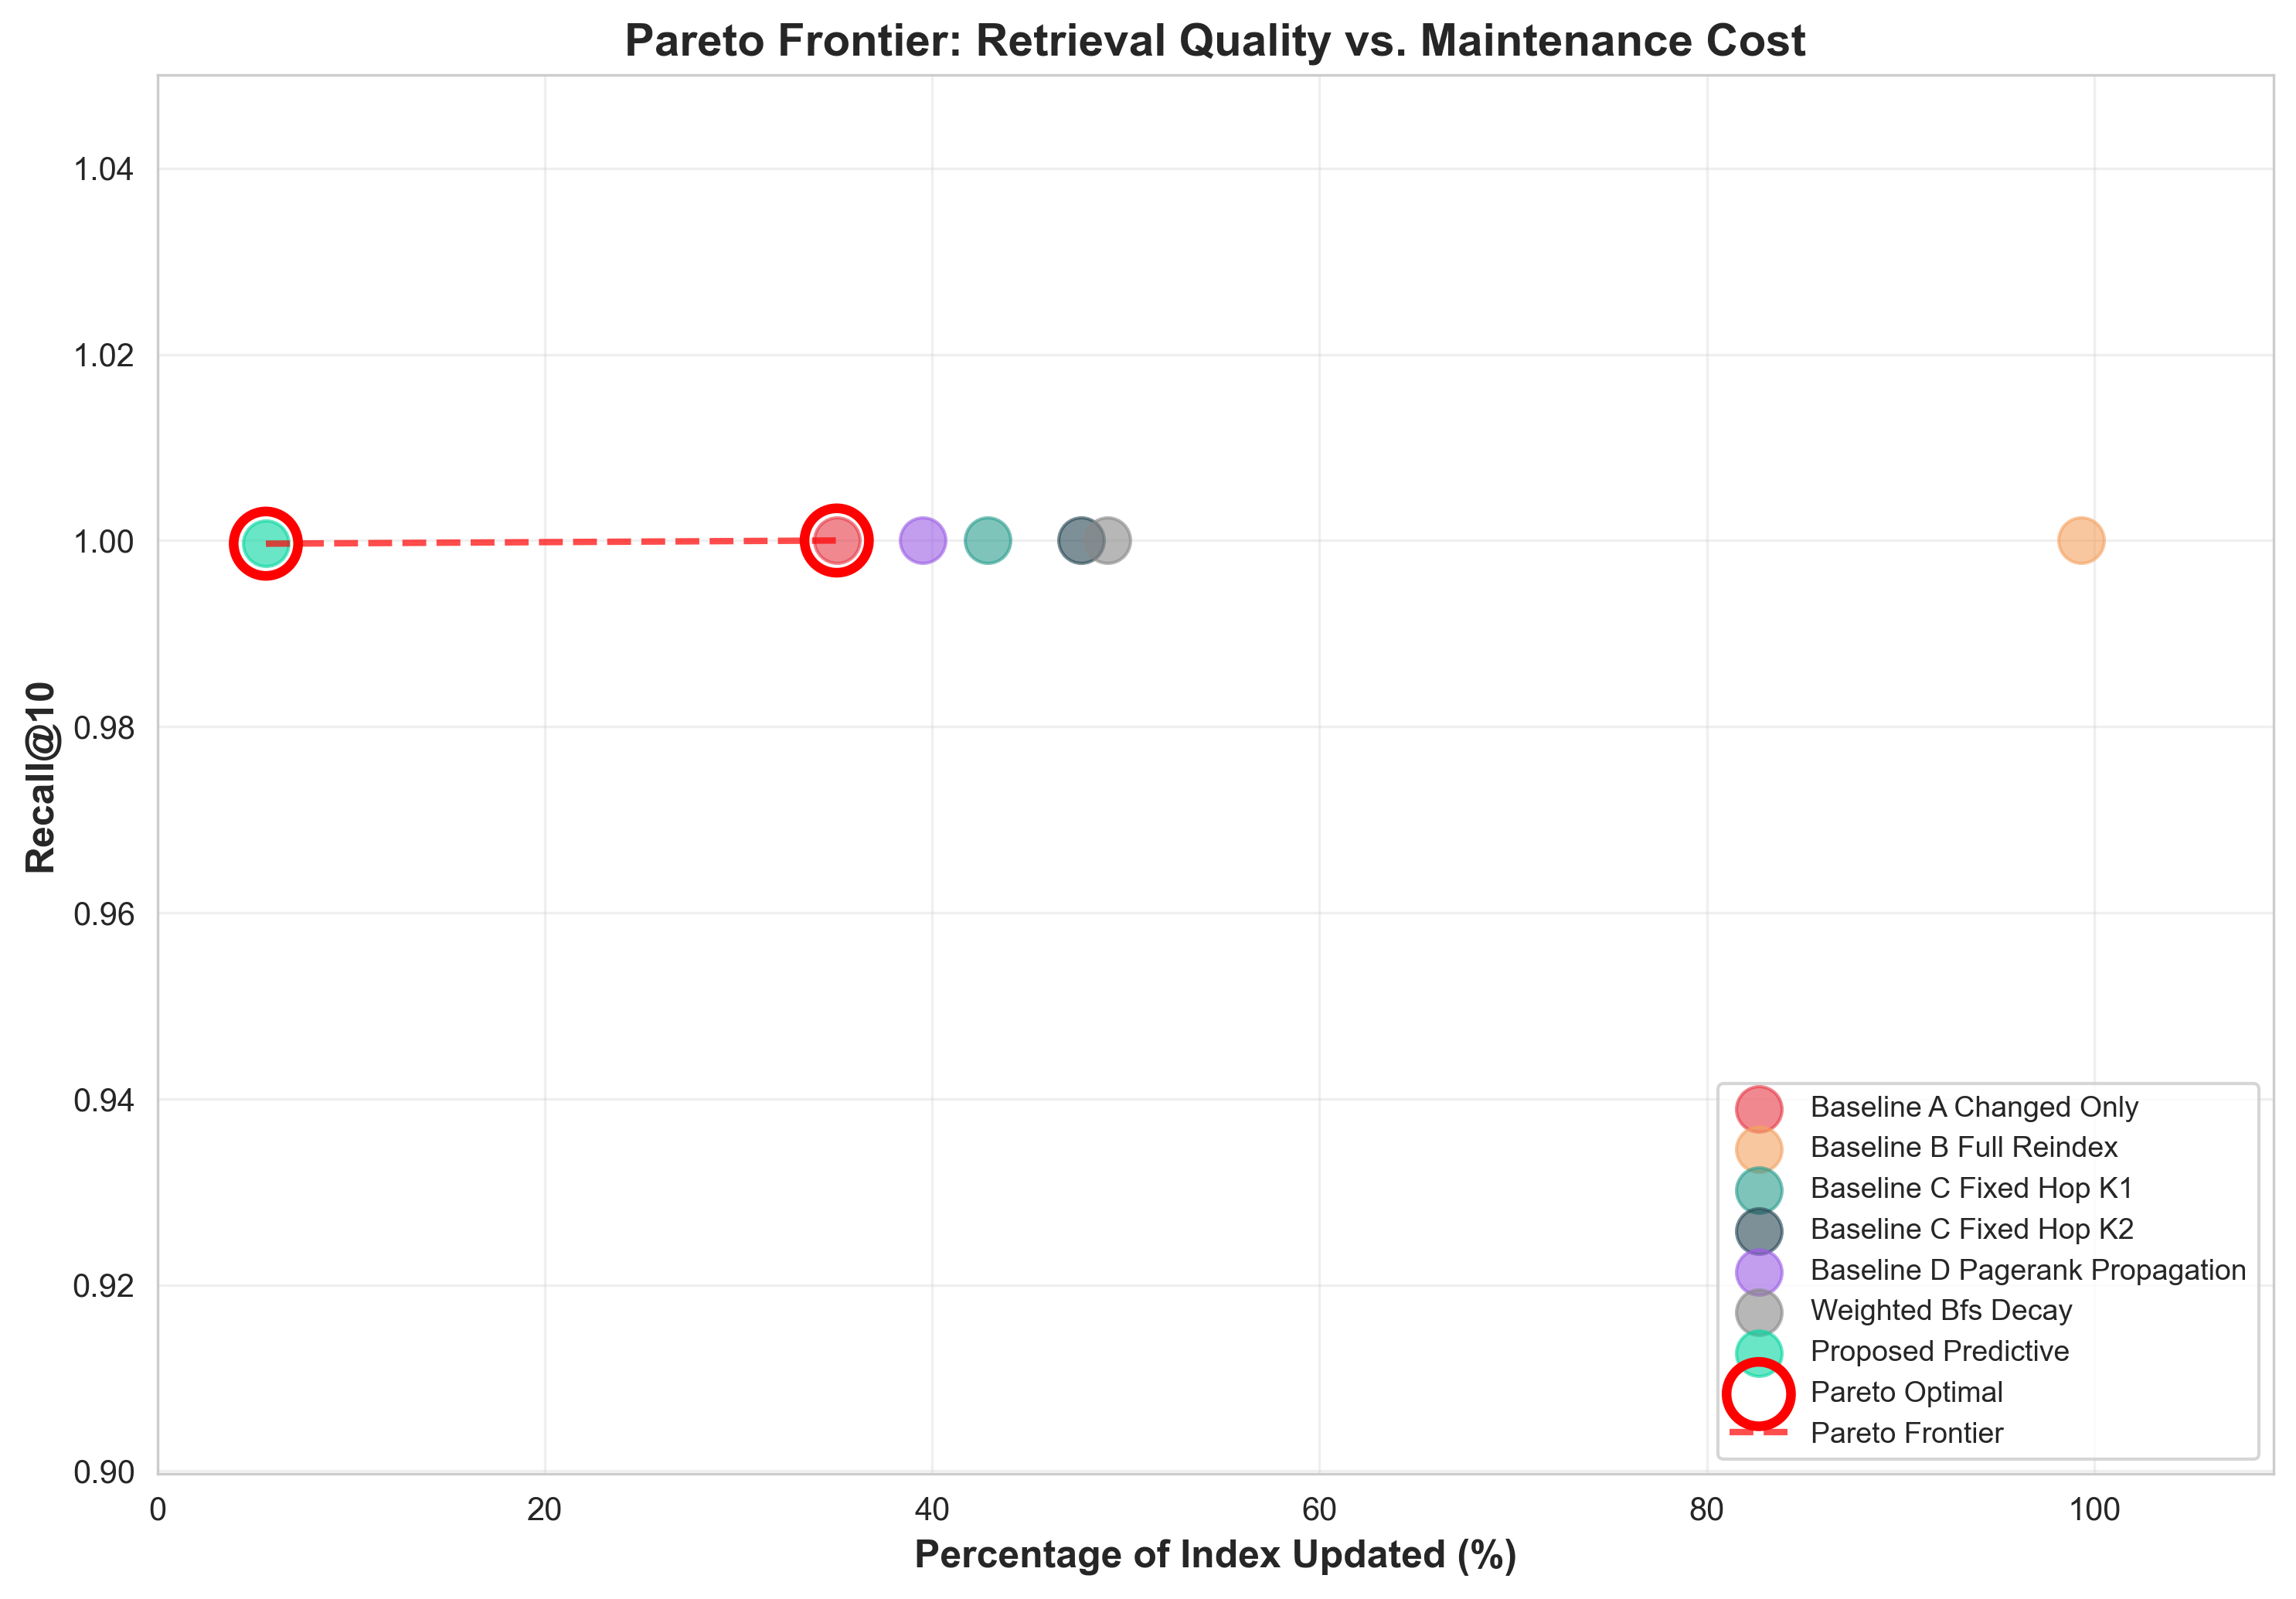

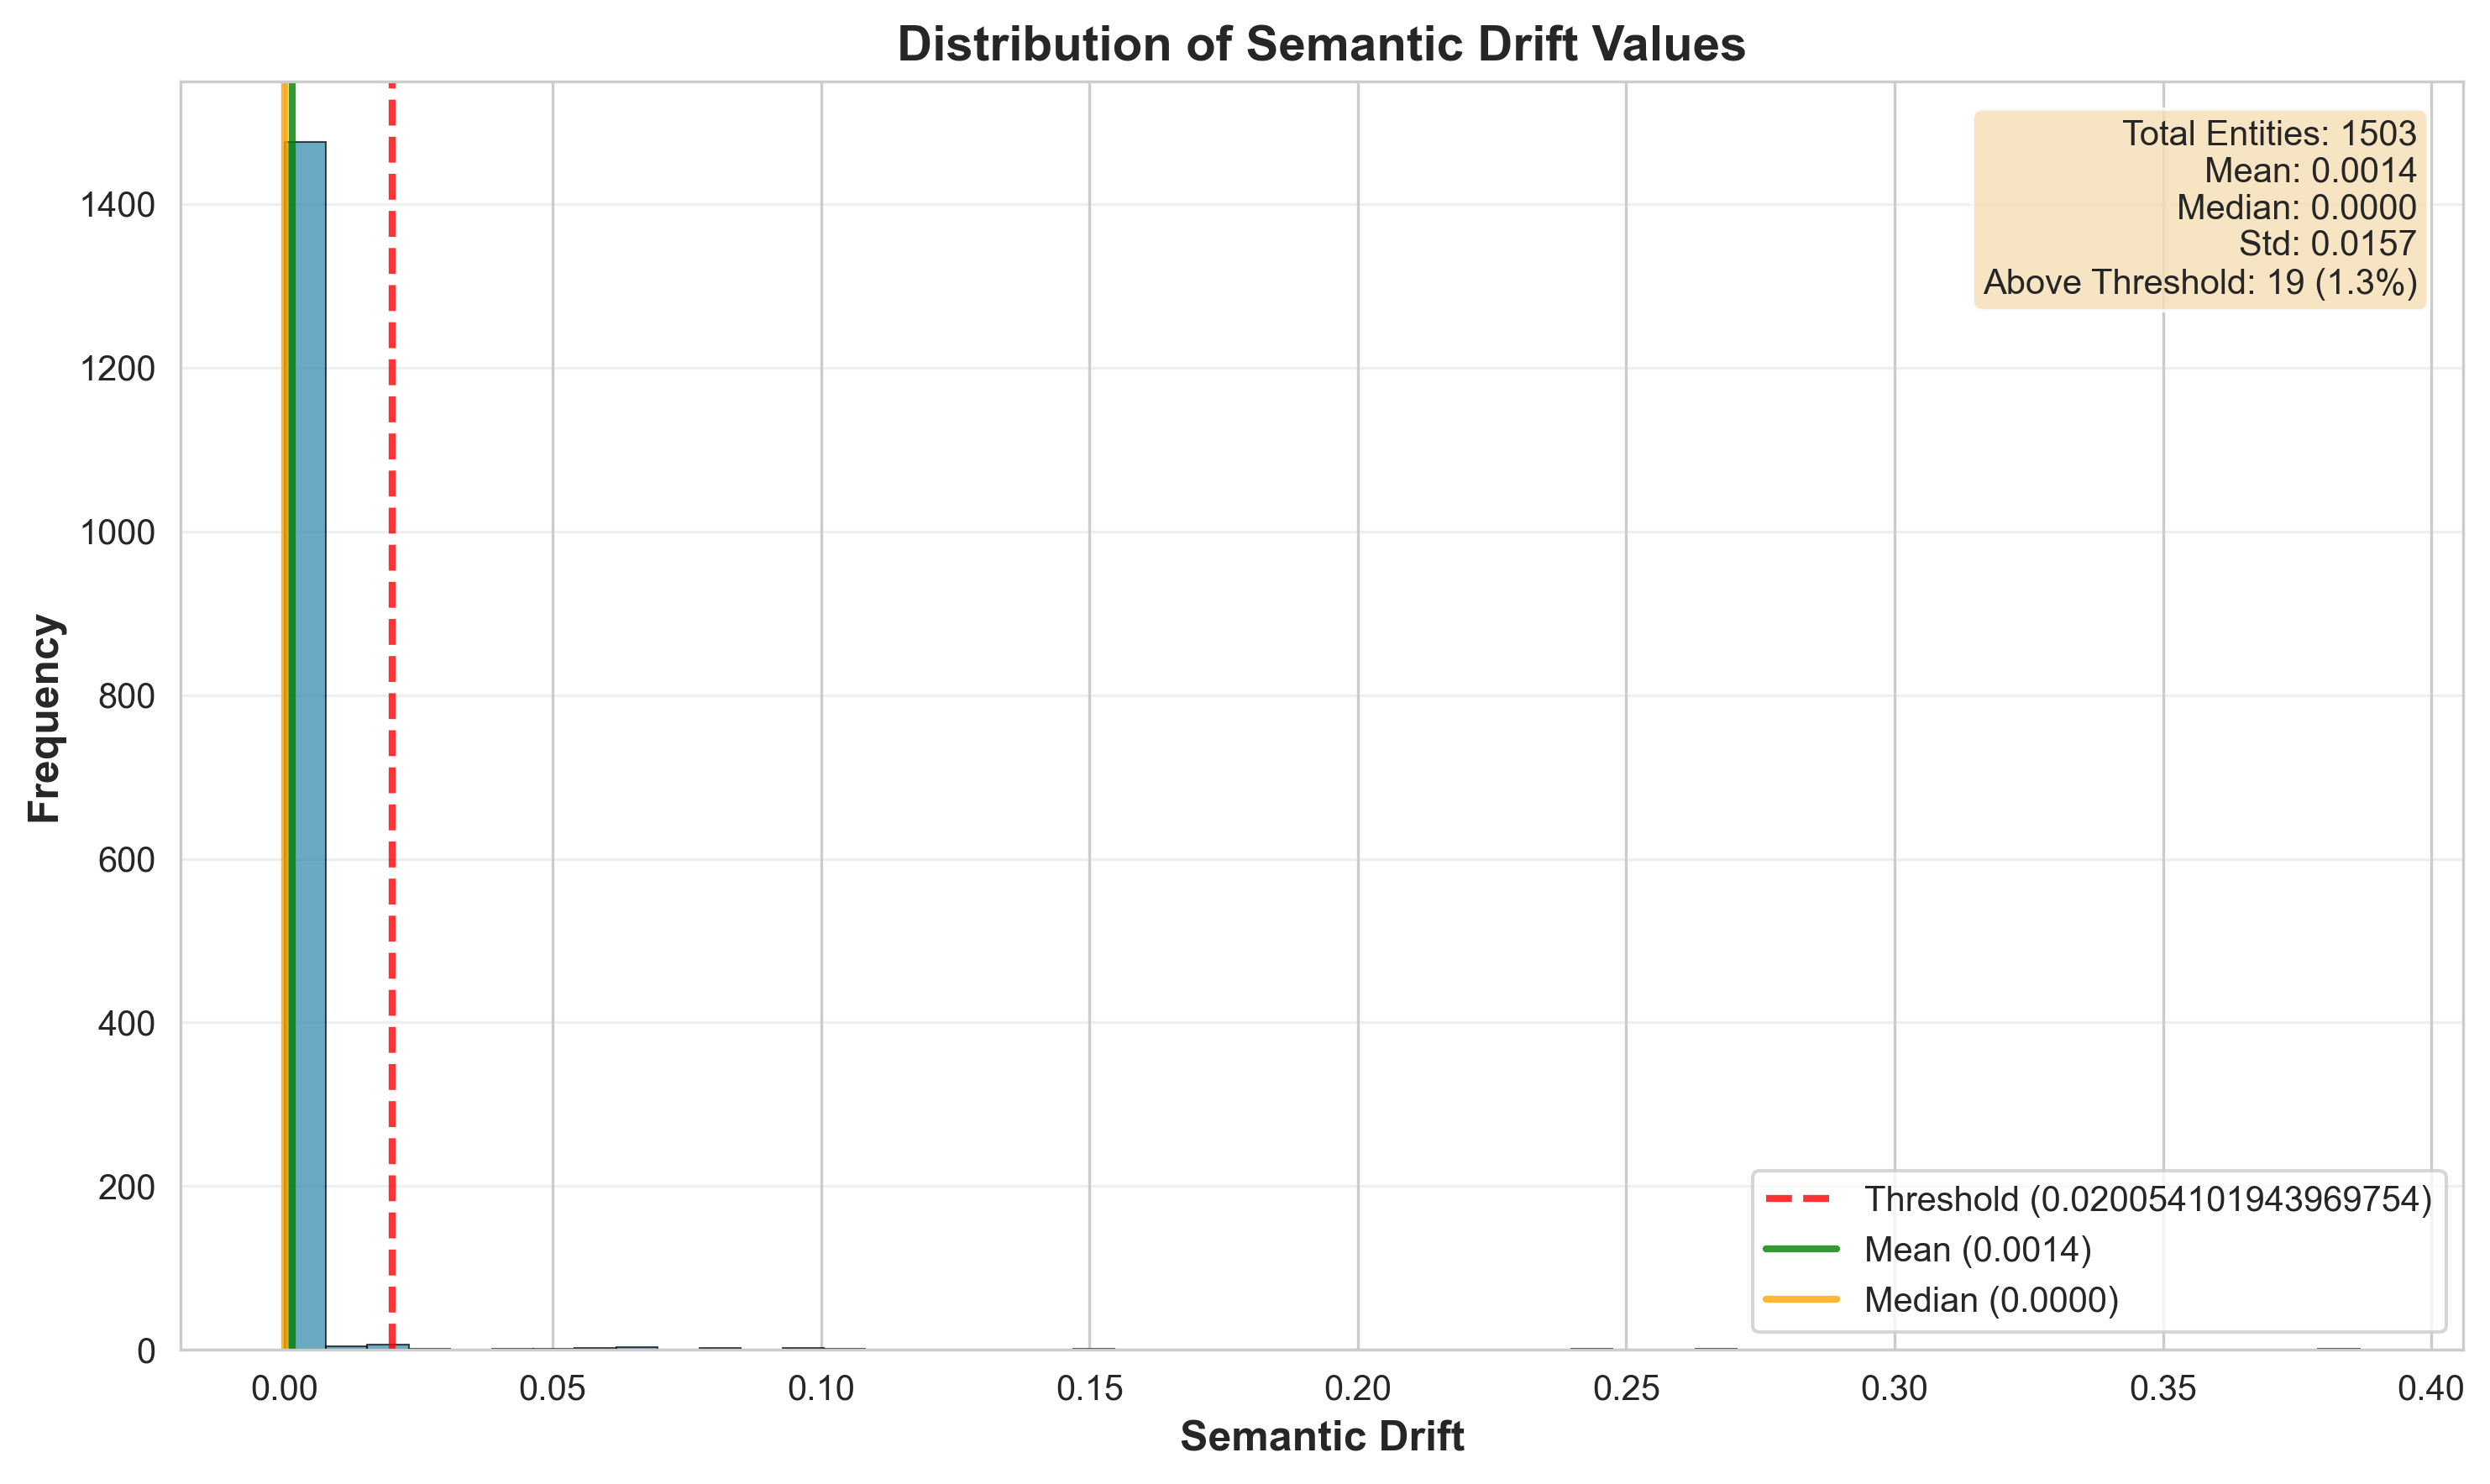

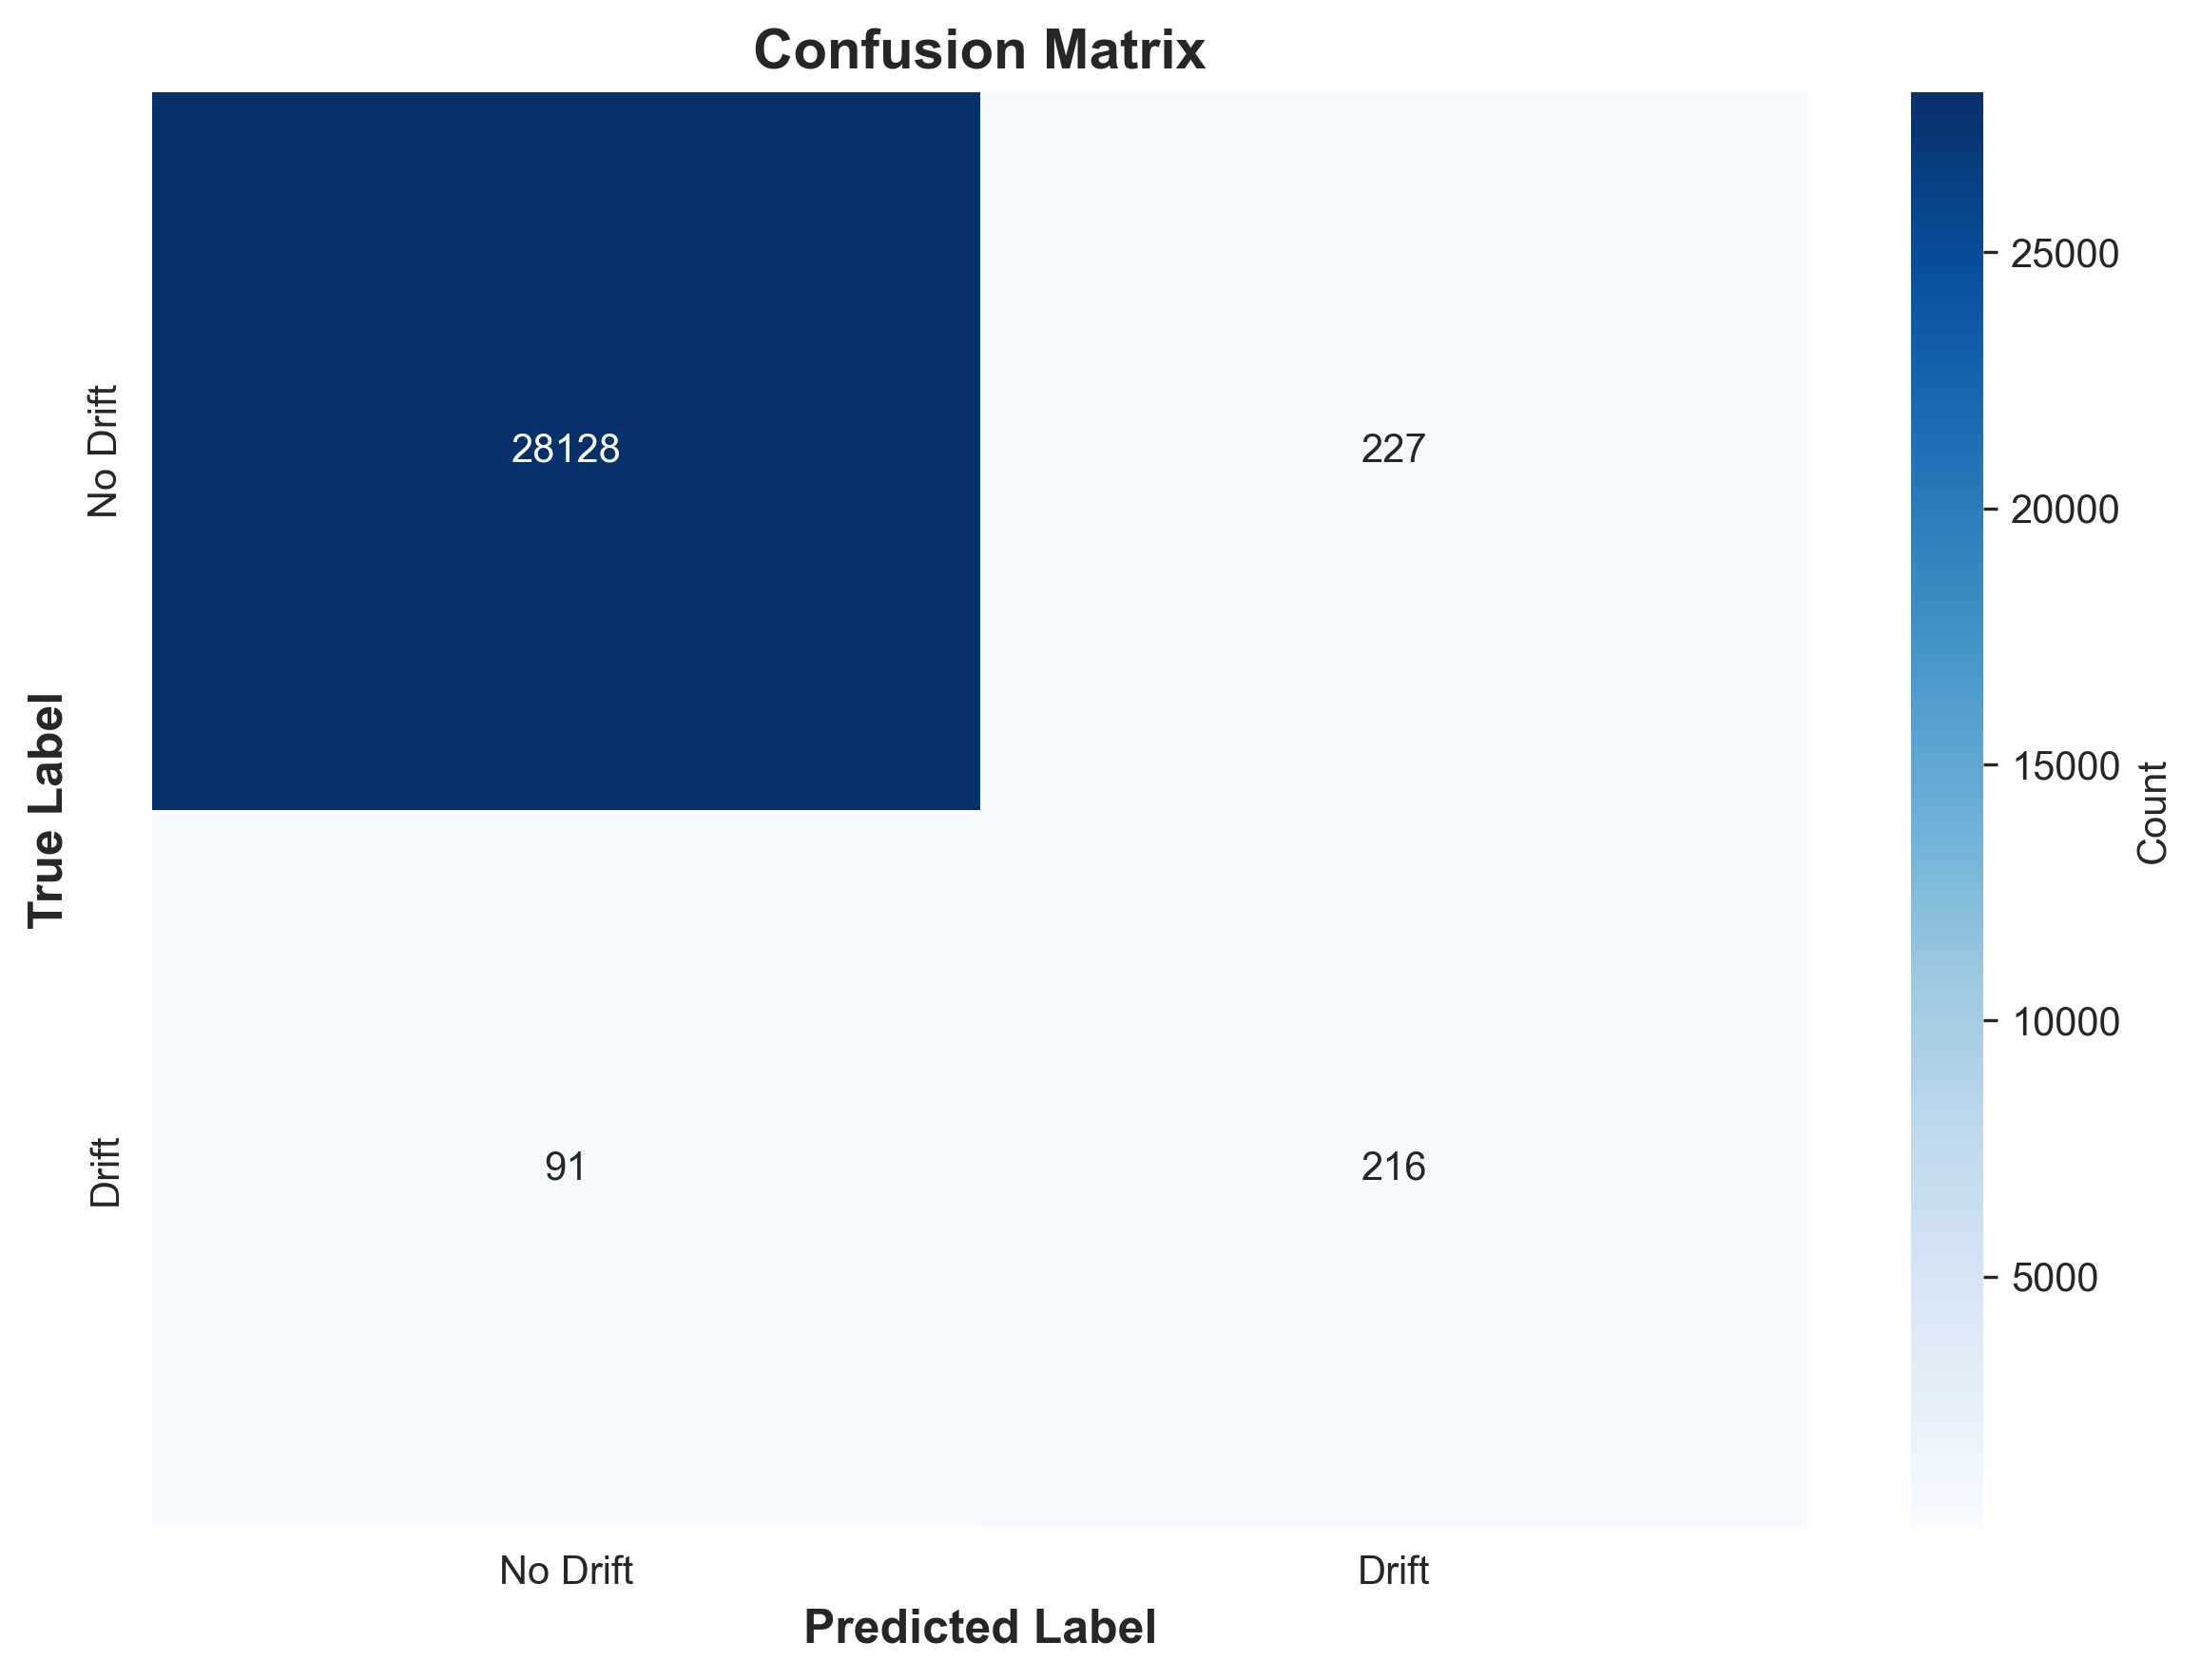

In [28]:
from IPython.display import Image, display

def show_plot(path: str):
    display(Image(filename=path))


results_for_viz = {
    "strategy_results": {name: row.to_dict() for name, row in averaged_results.iterrows()},
    "drift_by_distance": drift_by_distance,
}
feature_importance = predictor.get_feature_importance()

with timed("6_visualize", "plots"):
    plot_paths = []

    if drift_by_distance:
        plot_paths.append(visualizer.plot_drift_decay(drift_by_distance))

    if feature_importance:
        plot_paths.append(visualizer.plot_feature_importance(feature_importance))

    plot_paths.append(visualizer.plot_strategy_comparison(results_for_viz["strategy_results"]))
    plot_paths.append(visualizer.plot_ranking_metrics(results_for_viz["strategy_results"]))

    pareto_df = evaluator.compute_pareto_frontier(results_for_viz["strategy_results"],
                                                   recall_metric=PRIMARY_RECALL_COL)
    cost_df = evaluator.compute_maintenance_cost(results_for_viz["strategy_results"])
    cost_df = cost_df.merge(
        pd.DataFrame([{"strategy": k, "recall": v.get(PRIMARY_RECALL_COL, 0)}
                      for k, v in results_for_viz["strategy_results"].items()]),
        on="strategy",
    )
    plot_paths.append(visualizer.plot_pareto_frontier(pareto_df, cost_df))

    all_drifts_flat = {}
    for d in drifts_history.values():
        all_drifts_flat.update(d)
    if all_drifts_flat:
        plot_paths.append(visualizer.plot_drift_distribution(all_drifts_flat, threshold))

    if all_predictions and all_labels:
        plot_paths.append(visualizer.plot_confusion_matrix(np.array(all_labels), np.array(all_predictions)))

for p in plot_paths:
    show_plot(p)

In [29]:
with timed("6_visualize", "summary_report"):
    report_path = visualizer.generate_summary_report({
        "feature_importance": feature_importance or {},
        "strategy_results": results_for_viz["strategy_results"],
    })

print(Path(report_path).read_text())
print(f"\nAll plots + summary report saved under: {results_dir}")

PREDICTIVE SEMANTIC CACHE INVALIDATION - EXPERIMENT SUMMARY

TOP 10 FEATURE IMPORTANCES
--------------------------------------------------------------------------------
1. gtd_change_class: 0.2024
2. data_flow_distance: 0.1799
3. distance_to_modified_directed: 0.1264
4. distance_to_modified_undirected: 0.0834
5. taint_reachability_score: 0.0738
6. is_modified: 0.0665
7. pagerank_impact: 0.0612
8. gtd_local_edge_churn: 0.0326
9. sm_mean_drift: 0.0205
10. sm_high_drift_ratio: 0.0192

STRATEGY COMPARISON
--------------------------------------------------------------------------------

BASELINE_A_CHANGED_ONLY
  Entities Updated: 231.75 / 655.7954545454545 (35.07%)
  Recall@5:          0.9991
  Recall@10:         1.0000
  MRR:               1.0000
  nDCG@10:           1.0000
  Rank Correlation:  1.0000
  Evaluation Time:   0.0000s

BASELINE_B_FULL_REINDEX
  Entities Updated: 651.4090909090909 / 655.7954545454545 (99.33%)
  Recall@5:          1.0000
  Recall@10:         1.0000
  MRR:        

## Timing summary

Everything timed above, broken down by stage and sub-step, sorted by total
time descending — this is what to look at to see where the pipeline actually
spends its time.

In [30]:
by_stage = timing_table(group_cols=("stage",))
by_stage

,stage,calls,total_seconds,mean_seconds
0,2_parse_embed,600,1238.792836,2.064655
1,3_drift_features,597,280.665286,0.470126
2,5_evaluate,396,111.042484,0.280410
3,6_visualize,2,2.102220,1.051110
4,4_train,5,0.962402,0.192480
5,1_harvest,1,0.084861,0.084861
6,0_setup,2,0.037366,0.018683


In [31]:
by_substage = timing_table(group_cols=("stage", "substage"))
by_substage

,stage,substage,calls,total_seconds,mean_seconds
0,2_parse_embed,parse,150,872.062228,5.813748
1,2_parse_embed,embed,150,347.568538,2.317124
2,3_drift_features,extract_features,149,255.064034,1.711839
3,5_evaluate,strategy::baseline_c_fixed_hop_k2,44,46.355127,1.053526
4,5_evaluate,strategy::baseline_c_fixed_hop_k1,44,46.277309,1.051757
5,3_drift_features,modified_entities,149,21.960212,0.147384
6,2_parse_embed,checkout,150,15.762273,0.105082
7,5_evaluate,generate_queries,44,10.379969,0.235908
8,3_drift_features,gtd,149,3.487030,0.023403
9,2_parse_embed,rsd_add_commit,150,3.399796,0.022665


In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_stage["stage"][::-1], by_stage["total_seconds"][::-1])
ax.set_xlabel("Total seconds")
ax.set_title("Time per pipeline stage")
plt.tight_layout()
plt.show()

grand_total = sum(t["seconds"] for t in TIMINGS)
print(f"\nTotal measured wall-clock time: {grand_total:.2f}s ({grand_total/60:.1f} min)")


Total measured wall-clock time: 1633.69s (27.2 min)
